## modeling on STN_0001

### train set <2025-08-01,  test set >2025-08-01

### output:
- columns to output for modelling: 
        - canonical_station_id, ts_hour, station_netflow, model_netflow

### for dashboarding: 
- additional column 
        ⁠- canonical_station_id, ts_hour, num_available_bikes, num_available_docks
- powerbi formula -> 10% capacity or lower to be flagged out
- powerbi timestamp -> transform to Montreal ts


In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, explode, regexp_extract
from pyspark.sql.types import StructType, ArrayType, StringType, LongType, DoubleType, BooleanType
from pyspark.sql.functions import udf
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml.feature import VectorAssembler

import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import math
import geopandas as gpd
import os
import pyproj
import datetime
import folium

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import seaborn as sns

In [2]:
# read 2 functions from bixi-analytics/utils/yc__loss_func.py
import sys
sys.path.append('../utils')  # go up one level
from yc__loss_func import asymmetric_loss_col, asymmetric_loss_mean


In [3]:
# Stop any existing SparkSession to avoid conflicts
if 'spark' in locals() and spark is not None:
    spark.stop()

spark = SparkSession.builder.appName("stn0001-modeling").getOrCreate()
print(spark.version)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/18 16:34:16 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.249.2.66 instead (on interface en0)
26/04/18 16:34:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/18 16:34:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/18 16:34:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/18 16:34:20 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


4.1.1


In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0

    # Convert degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(dphi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))

    return R * c

# Register as a Spark UDF
haversine_km_udf = udf(haversine_km, DoubleType())

Get Data from GOLD

In [5]:
gold_parquet_path = '../../data/gold/station_flow/station_id=STN_0001_new/'

# Load the parquet files into a Spark DataFrame
gold_0001_df = spark.read.parquet(gold_parquet_path)

# --- IGNORE --- not required –––––––––
# # Filter rides to include only months between April (4) and October (10) for both start and end times
# ride_df = ride_df.filter(
#     (F.month("start_time_ms") >= 4) & (F.month("start_time_ms") <= 10) &
#     (F.month("end_time_ms") >= 4) & (F.month("end_time_ms") <= 10)
# )

print(f"Loaded and filtered gold_0001_df with {gold_0001_df.count()} rows and {len(gold_0001_df.columns)} columns.")
gold_0001_df.printSchema()
gold_0001_df.show(5)

Loaded and filtered gold_0001_df with 24614 rows and 64 columns.
root
 |-- ts_hour: timestamp (nullable = true)
 |-- station_inflow: long (nullable = true)
 |-- station_outflow: long (nullable = true)
 |-- station_netflow: long (nullable = true)
 |-- radius100m_inflow_lag1: long (nullable = true)
 |-- radius100m_outflow_lag1: long (nullable = true)
 |-- radius100m_inflow_lag12: long (nullable = true)
 |-- radius100m_outflow_lag12: long (nullable = true)
 |-- radius100m_inflow_rollmean6: double (nullable = true)
 |-- radius100m_outflow_rollmean6: double (nullable = true)
 |-- radius100m_inflow_rollmean12: double (nullable = true)
 |-- radius100m_outflow_rollmean12: double (nullable = true)
 |-- radius100m_inflow_rollsum6: long (nullable = true)
 |-- radius100m_outflow_rollsum6: long (nullable = true)
 |-- radius100m_inflow_rollsum12: long (nullable = true)
 |-- radius100m_outflow_rollsum12: long (nullable = true)
 |-- radius200m_inflow_lag1: long (nullable = true)
 |-- radius200m_outflo

26/04/18 16:34:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------------+--------------+---------------+---------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+---------------------------+----------------------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+---------------------------+----------------------------+----------------------+-----------------------+-----------------------+------------------------+---------------------------+----------------------------+----------------------------+-----------------------------+--------------------------+---------------------------+-----------------

In [6]:
# !pip install geopandas pyogrio

## Prediction Target: Inflow
## Output Model: Inflow model

feature importance

In [7]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_inflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_inflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [8]:
# fill numeric nulls with 0 for a stable exploratory screen
fill_map = {c: 0.0 for c in NUMERIC_COLS}
fill_map.update({c: 0 for c in BOOLEAN_COLS})

screen_df = gold_0001_df.fillna(fill_map)

# string index + one-hot encode temp_bin
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in CATEGORICAL_COLS]

screen_feature_inputs = NUMERIC_COLS + BOOLEAN_COLS + [f"{c}_ohe" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=screen_feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
screen_model = screen_pipe.fit(screen_df)
screen_ready = screen_model.transform(screen_df).select(TIME_COL, TARGET_COL, "features_raw", "features_scaled")
print("Exploratory screening rows:", screen_ready.count())

# helper to expand feature names after OHE
def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(s for s in pipeline_model.stages if hasattr(s, 'getOutputCol') and s.getOutputCol() == f"{c}_idx")
        labels = list(idx_model.labels) + ["__unknown__"]
        drop_last = True  # default behavior of Spark OHE
        usable = labels[:-1] if drop_last and len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names

screen_feature_names = get_feature_names_from_pipeline_model(screen_model, NUMERIC_COLS, BOOLEAN_COLS, CATEGORICAL_COLS)
len(screen_feature_names), screen_feature_names[:10]

Exploratory screening rows: 24614


(68,
 ['radius100m_inflow_lag1',
  'radius100m_outflow_lag1',
  'radius100m_inflow_lag12',
  'radius100m_outflow_lag12',
  'radius100m_inflow_rollmean6',
  'radius100m_outflow_rollmean6',
  'radius100m_inflow_rollmean12',
  'radius100m_outflow_rollmean12',
  'radius100m_inflow_rollsum6',
  'radius100m_outflow_rollsum6'])

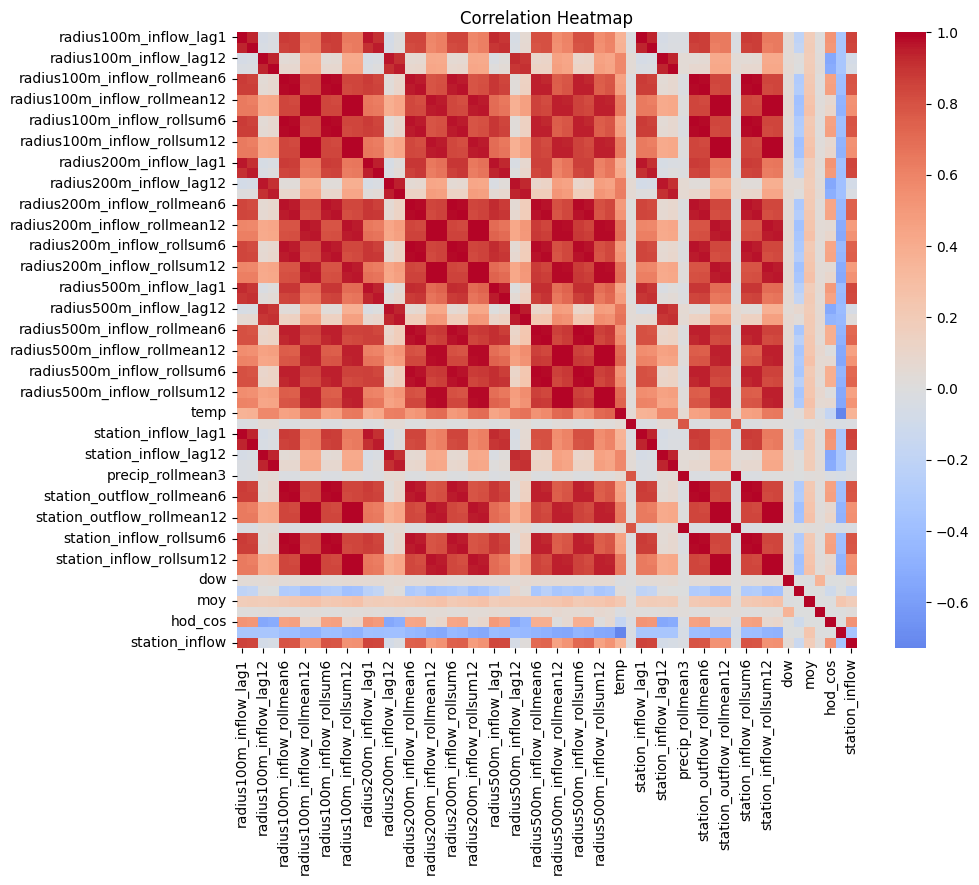

In [9]:
pdf = screen_df.select(NUMERIC_COLS + [TARGET_COL]).toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

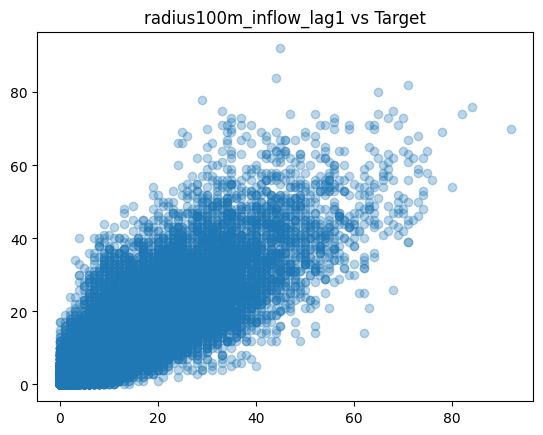

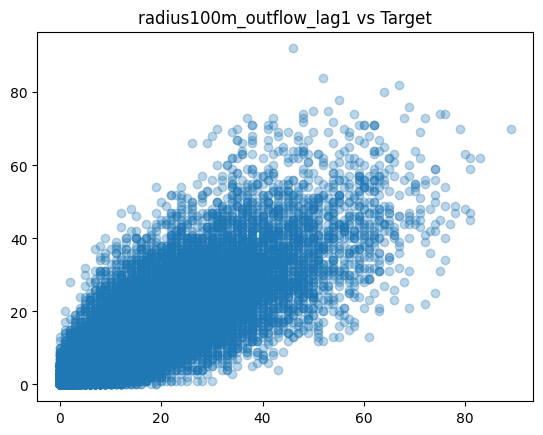

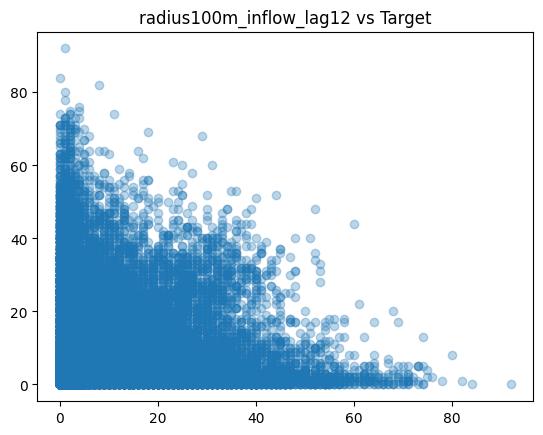

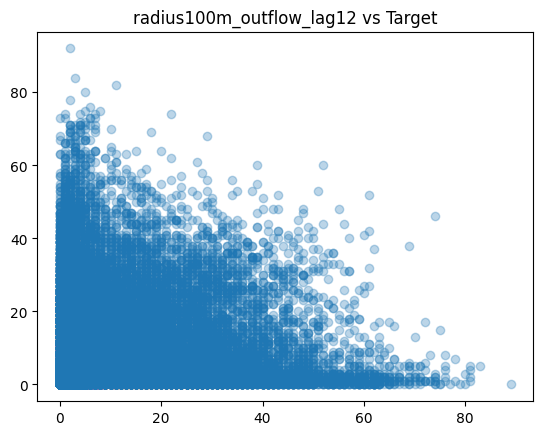

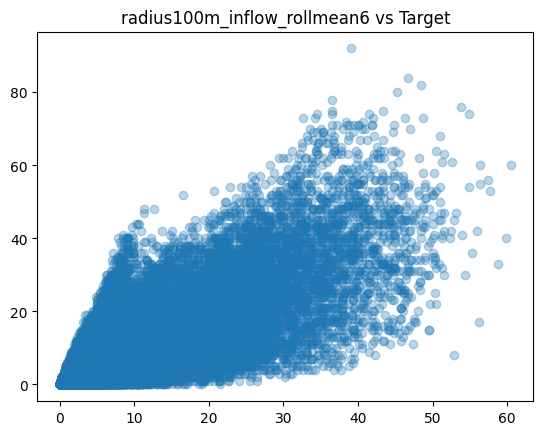

In [10]:
for col in NUMERIC_COLS[:5]:
    plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
    plt.title(f"{col} vs Target")
    plt.show()

In [11]:
# Define the evaluators for each metric
evaluator_rmse = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="r2")

print("Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2")

Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2


In [12]:
preview = gold_0001_df.limit(1).toPandas()
preview.to_csv("schema_preview.csv", index=False)

In [13]:
# Time-based Split

# define cutoff date
cutoff_date = "2025-08-01"
# split data
train_df = gold_0001_df.filter(F.col("ts_hour") < cutoff_date)
test_df  = gold_0001_df.filter(F.col("ts_hour") >= cutoff_date)

# sanity checks
print(f"Cutoff date: {cutoff_date}")
print(f"Data ready. Total rows: {gold_0001_df.count()}")
print(f"Training set: {train_df.count()} rows")
print(f"Testing set: {test_df.count()} rows")


Cutoff date: 2025-08-01
Data ready. Total rows: 24614
Training set: 20185 rows
Testing set: 4429 rows


In [14]:
# exploratory tree-based importance
rf_screen = RandomForestRegressor(
    featuresCol="features_raw",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    numTrees=80,
    maxDepth=8,
    seed=42
)
rf_screen_model = rf_screen.fit(screen_ready)

rf_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "importance": list(rf_screen_model.featureImportances.toArray())
}).sort_values("importance", ascending=False)

rf_importance_pdf.head(20)

26/04/18 16:34:59 WARN DAGScheduler: Broadcasting large task binary with size 1191.3 KiB
26/04/18 16:35:02 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/18 16:35:06 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


,feature,importance
25,radius500m_outflow_lag1,0.230888
0,radius100m_inflow_lag1,0.178647
13,radius200m_outflow_lag1,0.117546
38,station_inflow_lag1,0.077279
1,radius100m_outflow_lag1,0.076208
39,station_outflow_lag1,0.038412
56,hod_cos,0.037073
53,hod,0.034520
12,radius200m_inflow_lag1,0.030938
4,radius100m_inflow_rollmean6,0.025519


In [15]:
# exploratory linear importance using standardized features
lr_screen = LinearRegression(
    featuresCol="features_scaled",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)
lr_screen_model = lr_screen.fit(screen_ready)

lr_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "coefficient": list(lr_screen_model.coefficients.toArray())
})
lr_importance_pdf["abs_coefficient"] = lr_importance_pdf["coefficient"].abs()
lr_importance_pdf = lr_importance_pdf.sort_values("abs_coefficient", ascending=False)

lr_importance_pdf.head(20)

26/04/18 16:35:12 WARN Instrumentation: [e2723414] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:35:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/18 16:35:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/04/18 16:35:14 WARN Instrumentation: [e2723414] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,9.619236,9.619236
31,radius500m_outflow_rollmean12,9.539879,9.539879
30,radius500m_inflow_rollmean12,-7.974498,7.974498
34,radius500m_inflow_rollsum12,-7.914047,7.914047
24,radius500m_inflow_lag1,6.657782,6.657782
29,radius500m_outflow_rollmean6,-4.780451,4.780451
33,radius500m_outflow_rollsum6,-4.765004,4.765004
25,radius500m_outflow_lag1,4.276516,4.276516
27,radius500m_outflow_lag12,-3.035579,3.035579
8,radius100m_inflow_rollsum6,2.985931,2.985931


In [16]:
# choose candidate features from the exploratory screen
TOP_N_TREE = 25
TOP_N_LINEAR = 25

tree_top = rf_importance_pdf.head(TOP_N_TREE)["feature"].tolist()
linear_top = lr_importance_pdf.head(TOP_N_LINEAR)["feature"].tolist()

screen_top_union = sorted(set(tree_top) | set(linear_top))
print("Union of shortlisted features:", len(screen_top_union))
screen_top_union[:20]

Union of shortlisted features: 41


['dow_cos',
 'hod',
 'hod_cos',
 'radius100m_inflow_lag1',
 'radius100m_inflow_lag12',
 'radius100m_inflow_rollmean12',
 'radius100m_inflow_rollmean6',
 'radius100m_inflow_rollsum12',
 'radius100m_inflow_rollsum6',
 'radius100m_outflow_lag1',
 'radius100m_outflow_rollmean12',
 'radius100m_outflow_rollsum12',
 'radius100m_outflow_rollsum6',
 'radius200m_inflow_lag1',
 'radius200m_inflow_lag12',
 'radius200m_inflow_rollmean12',
 'radius200m_inflow_rollsum12',
 'radius200m_outflow_lag1',
 'radius200m_outflow_rollmean6',
 'radius200m_outflow_rollsum12']

In [17]:
time_bounds = gold_0001_df.select(
    F.min(TIME_COL).alias("min_ts"),
    F.max(TIME_COL).alias("max_ts")
).first()

min_ts = time_bounds["min_ts"]
max_ts = time_bounds["max_ts"]

timeline = gold_0001_df.select(TIME_COL).distinct().orderBy(TIME_COL)
n_time_points = timeline.count()
split_idx = int(math.floor(n_time_points * 0.8))

split_ts = timeline.collect()[split_idx - 1][TIME_COL] if split_idx > 0 else min_ts

print("Min timestamp:", min_ts)
print("Max timestamp:", max_ts)
print("Distinct time points:", n_time_points)
print("80/20 split timestamp:", split_ts)

train_full_df = gold_0001_df.filter(F.col(TIME_COL) <= F.lit(split_ts))
test_df = gold_0001_df.filter(F.col(TIME_COL) > F.lit(split_ts))

print("Train_full rows:", train_full_df.count())
print("Test rows:", test_df.count())

Min timestamp: 2023-04-12 23:00:00
Max timestamp: 2026-02-01 12:00:00
Distinct time points: 24614
80/20 split timestamp: 2025-07-11 09:00:00
Train_full rows: 19691
Test rows: 4923


##### 8. Create a validation window inside the training period

For hyperparameter tuning, avoid peeking at the test set.  
This notebook splits the 80% training window again into:
- earlier **train**
- later **validation**

The final 20% remains untouched for final evaluation.

In [18]:
train_timeline = train_full_df.select(TIME_COL).distinct().orderBy(TIME_COL)
n_train_time_points = train_timeline.count()
val_start_idx = int(math.floor(n_train_time_points * 0.8))
val_start_ts = train_timeline.collect()[val_start_idx - 1][TIME_COL] if val_start_idx > 0 else split_ts

train_df = train_full_df.filter(F.col(TIME_COL) <= F.lit(val_start_ts))
val_df = train_full_df.filter(F.col(TIME_COL) > F.lit(val_start_ts))

print("Train rows:", train_df.count())
print("Validation rows:", val_df.count())
print("Validation start timestamp:", val_start_ts)

Train rows: 15752
Validation rows: 3939
Validation start timestamp: 2025-01-28 06:00:00


use all engineered features

In [19]:
## set USE_SCREENED_FEATURES to True if want to use reduced feature set
USE_SCREENED_FEATURES = False

if USE_SCREENED_FEATURES:
    # screen_top_union contains expanded names after OHE, so for actual assembly we keep all original columns
    # and later inspect importance again on the training-only data
    print("Using original columns but screened results only as guidance.")

MODEL_NUMERIC_COLS = NUMERIC_COLS
MODEL_BOOLEAN_COLS = BOOLEAN_COLS
MODEL_CATEGORICAL_COLS = CATEGORICAL_COLS

fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

train_df = train_df.fillna(fill_map)
val_df = val_df.fillna(fill_map)
test_df = test_df.fillna(fill_map)

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in MODEL_CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in MODEL_CATEGORICAL_COLS]

feature_inputs = MODEL_NUMERIC_COLS + MODEL_BOOLEAN_COLS + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

prep_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
prep_model = prep_pipe.fit(train_df)

train_ready = prep_model.transform(train_df)
val_ready = prep_model.transform(val_df)
test_ready = prep_model.transform(test_df)

model_feature_names = get_feature_names_from_pipeline_model(prep_model, MODEL_NUMERIC_COLS, MODEL_BOOLEAN_COLS, MODEL_CATEGORICAL_COLS)
print("Prepared feature count:", len(model_feature_names))

Prepared feature count: 68


In [20]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### 11. First-round baseline training

Design choice:
- tree models use `features_raw`
- linear models use `features_scaled`
- Poisson GLR assumes a non-negative target, so use it mainly for `station_inflow` or `station_outflow`

Model Training - To Try All types of Time Series Regression supported by Spark

In [21]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}

In [22]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 4.732635274748987, 'mae': 2.7629300849620457, 'r2': 0.88074256434538}


26/04/18 16:36:34 WARN DAGScheduler: Broadcasting large task binary with size 1434.7 KiB
26/04/18 16:36:37 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/18 16:36:41 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/04/18 16:36:44 WARN DAGScheduler: Broadcasting large task binary with size 1156.3 KiB


RandomForestRegressor {'rmse': 4.759375911060456, 'mae': 2.8168106767983367, 'r2': 0.8793910851252617}


DecisionTreeRegressor {'rmse': 5.068600552002991, 'mae': 2.96860052824266, 'r2': 0.8632096291705313}
LinearRegression {'rmse': 5.530561452230217, 'mae': 3.4681709702978782, 'r2': 0.8371387220140158}


26/04/18 16:36:57 WARN Instrumentation: [50e1fc18] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:36:58 WARN Instrumentation: [50e1fc18] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:36:58 WARN Instrumentation: [50e1fc18] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:36:59 WARN Instrumentation: [50e1fc18] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:36:59 WARN Instrumentation: [50e1fc18] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:37:00 WARN Instrumentation: [50e1fc18] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:37:00 WARN Instrumentation: [50e1fc18] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:37:01 WARN Instrumentation: [50e1fc18] Cholesky solv

GeneralizedLinearRegression {'rmse': 6.003392859997659, 'mae': 3.6220430000623454, 'r2': 0.8081009067908121}


,model_name,features_col,rmse,mae,r2
0,GBTRegressor,features_raw,4.732635,2.762930,0.880743
1,RandomForestRegressor,features_raw,4.759376,2.816811,0.879391
2,DecisionTreeRegressor,features_raw,5.068601,2.968601,0.863210
3,LinearRegression,features_scaled,5.530561,3.468171,0.837139
4,GeneralizedLinearRegression,features_scaled,6.003393,3.622043,0.808101


#### 12. Training-only feature importance after the baseline round


In [23]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [24]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                        feature  importance
13      radius200m_outflow_lag1    0.278826
53                          hod    0.099774
4   radius100m_inflow_rollmean6    0.093289
                    feature  importance
13  radius200m_outflow_lag1    0.229300
0    radius100m_inflow_lag1    0.167522
25  radius500m_outflow_lag1    0.136229
                    feature  importance
13  radius200m_outflow_lag1    0.606676
24   radius500m_inflow_lag1    0.112280
53                      hod    0.093261
                          feature  coefficient  abs_coefficient
24         radius500m_inflow_lag1     4.267004         4.267004
35   radius500m_outflow_rollsum12     3.859706         3.859706
31  radius500m_outflow_rollmean12     3.837199         3.837199
                          feature  coefficient  abs_coefficient
35   radius500m_outflow_rollsum12     0.598127         0.598127
31  radius500m_outflow_rollmean12     0.585870         0.585870
56                        hod_cos     0.478846         0

#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [25]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")

In [26]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 4.94793457195782, 'mae': 2.986247025930224, 'r2': 0.8696451211981714}


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 4.6788427573569304, 'mae': 2.775500755706196, 'r2': 0.883438186987553}


26/04/18 16:39:39 WARN DAGScheduler: Broadcasting large task binary with size 1003.5 KiB
26/04/18 16:39:40 WARN DAGScheduler: Broadcasting large task binary with size 1006.3 KiB
26/04/18 16:39:40 WARN DAGScheduler: Broadcasting large task binary with size 1006.8 KiB
26/04/18 16:39:40 WARN DAGScheduler: Broadcasting large task binary with size 1007.8 KiB
26/04/18 16:39:41 WARN DAGScheduler: Broadcasting large task binary with size 1008.5 KiB
26/04/18 16:39:41 WARN DAGScheduler: Broadcasting large task binary with size 1010.8 KiB
26/04/18 16:39:41 WARN DAGScheduler: Broadcasting large task binary with size 1014.8 KiB
26/04/18 16:39:41 WARN DAGScheduler: Broadcasting large task binary with size 1017.0 KiB
26/04/18 16:39:42 WARN DAGScheduler: Broadcasting large task binary with size 1017.5 KiB
26/04/18 16:39:42 WARN DAGScheduler: Broadcasting large task binary with size 1018.5 KiB
26/04/18 16:39:42 WARN DAGScheduler: Broadcasting large task binary with size 1019.3 KiB
26/04/18 16:39:42 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 4.756039282925155, 'mae': 2.77627406315437, 'r2': 0.8795601350354338}

Tuning RandomForestRegressor


...

26/04/18 16:42:59 WARN Instrumentation: [b07a75fb] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:00 WARN Instrumentation: [b07a75fb] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:00 WARN Instrumentation: [b07a75fb] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:01 WARN Instrumentation: [b07a75fb] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:01 WARN Instrumentation: [b07a75fb] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:01 WARN Instrumentation: [b07a75fb] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:01 WARN Instrumentation: [b07a75fb] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:02 WARN Instrumentation: [b07a75fb] Cholesky solv

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 6.003392859997659, 'mae': 3.6220430000623454, 'r2': 0.8081009067908121}


26/04/18 16:43:29 WARN Instrumentation: [54060190] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:29 WARN Instrumentation: [54060190] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:29 WARN Instrumentation: [54060190] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:30 WARN Instrumentation: [54060190] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:30 WARN Instrumentation: [54060190] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:30 WARN Instrumentation: [54060190] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:43:30 WARN Instrumentation: [54060190] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:43:31 WARN Instrumentation: [54060190] Cholesky solv

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 6.006807711716676, 'mae': 3.6227587892875532, 'r2': 0.8078825325016205}
{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 6.366010623916299, 'mae': 3.9121823315294098, 'r2': 0.7842185476173709}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.068601,2.968601,0.863210
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",5.323608,3.062747,0.849099
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",6.029459,3.637654,0.806431
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",4.678843,2.775501,0.883438
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",4.756039,2.776274,0.879560
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",4.947935,2.986247,0.869645
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",6.003393,3.622043,0.808101
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",6.006808,3.622759,0.807883
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",6.366011,3.912182,0.784219
9,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",5.451650,3.427156,0.841753


In [27]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.068601,2.968601,0.863210
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",4.678843,2.775501,0.883438
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",6.003393,3.622043,0.808101
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",5.451650,3.427156,0.841753
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",4.467522,2.645277,0.893729


In [72]:
# print best_params_df random forest regressor params_json
best_params_pdf[best_params_pdf["model_name"] == "RandomForestRegressor"]

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",4.899923,3.006874,0.886074


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [28]:
train_full_ready = prep_model.transform(train_full_df.fillna(fill_map))
test_ready = prep_model.transform(test_df.fillna(fill_map))

final_results = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results
]).sort_values("rmse")

final_metrics_pdf

26/04/18 16:45:23 WARN Instrumentation: [81ac8dc1] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:45:24 WARN Instrumentation: [81ac8dc1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:45:24 WARN Instrumentation: [81ac8dc1] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:45:24 WARN Instrumentation: [81ac8dc1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:45:24 WARN Instrumentation: [81ac8dc1] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:45:25 WARN Instrumentation: [81ac8dc1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:45:25 WARN Instrumentation: [81ac8dc1] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:45:25 WARN Instrumentation: [81ac8dc1] Cholesky solv

,model_name,params_json,rmse,mae,r2
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",4.629682,2.961538,0.910992
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",4.859123,3.098584,0.901951
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.588783,3.519013,0.870293
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.282291,4.147459,0.836106
2,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",7.584241,4.441142,0.761135


In [29]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
25,radius500m_outflow_lag1,0.615588
24,radius500m_inflow_lag1,0.111059
53,hod,0.047907
12,radius200m_inflow_lag1,0.041175
30,radius500m_inflow_rollmean12,0.037952
4,radius100m_inflow_rollmean6,0.035797
6,radius100m_inflow_rollmean12,0.030763
0,radius100m_inflow_lag1,0.026658
56,hod_cos,0.016930
13,radius200m_outflow_lag1,0.008913



 GBTRegressor


,feature,importance
25,radius500m_outflow_lag1,0.230431
4,radius100m_inflow_rollmean6,0.104012
53,hod,0.079401
24,radius500m_inflow_lag1,0.078995
56,hod_cos,0.070040
6,radius100m_inflow_rollmean12,0.046388
30,radius500m_inflow_rollmean12,0.044624
0,radius100m_inflow_lag1,0.033957
12,radius200m_inflow_lag1,0.029447
55,dow_cos,0.029148



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,0.608981,0.608981
31,radius500m_outflow_rollmean12,0.599400,0.599400
56,hod_cos,0.488928,0.488928
25,radius500m_outflow_lag1,0.429750,0.429750
28,radius500m_inflow_rollmean6,-0.408064,0.408064
32,radius500m_inflow_rollsum6,-0.406723,0.406723
26,radius500m_inflow_lag12,0.298961,0.298961
30,radius500m_inflow_rollmean12,-0.298023,0.298023
34,radius500m_inflow_rollsum12,-0.292329,0.292329
57,moy_cos,-0.253218,0.253218



 LinearRegression


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,9.041158,9.041158
31,radius500m_outflow_rollmean12,8.953784,8.953784
30,radius500m_inflow_rollmean12,-7.130979,7.130979
34,radius500m_inflow_rollsum12,-7.065144,7.065144
24,radius500m_inflow_lag1,5.663437,5.663437
29,radius500m_outflow_rollmean6,-4.994579,4.994579
33,radius500m_outflow_rollsum6,-4.976673,4.976673
25,radius500m_outflow_lag1,4.748648,4.748648
27,radius500m_outflow_lag12,-3.162011,3.162011
48,station_inflow_rollsum6,2.776738,2.776738



 RandomForestRegressor


,feature,importance
25,radius500m_outflow_lag1,0.201057
0,radius100m_inflow_lag1,0.161694
13,radius200m_outflow_lag1,0.157775
38,station_inflow_lag1,0.070059
12,radius200m_inflow_lag1,0.051318
1,radius100m_outflow_lag1,0.039790
24,radius500m_inflow_lag1,0.036200
53,hod,0.035247
56,hod_cos,0.033934
4,radius100m_inflow_rollmean6,0.025835


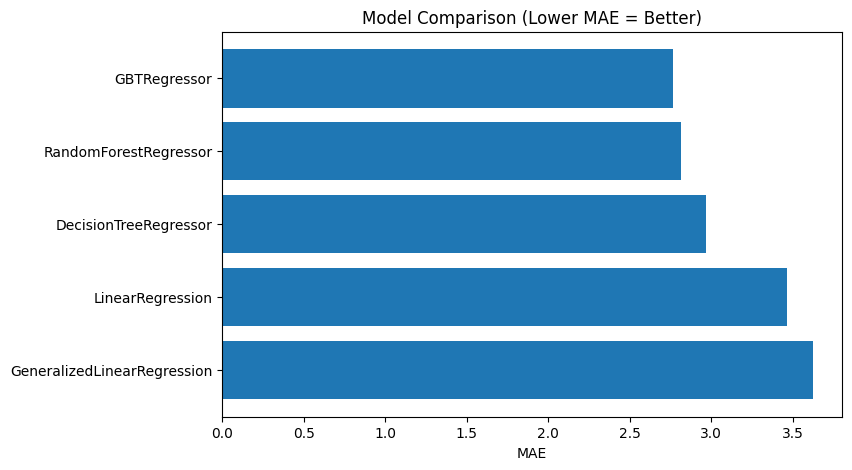

In [30]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

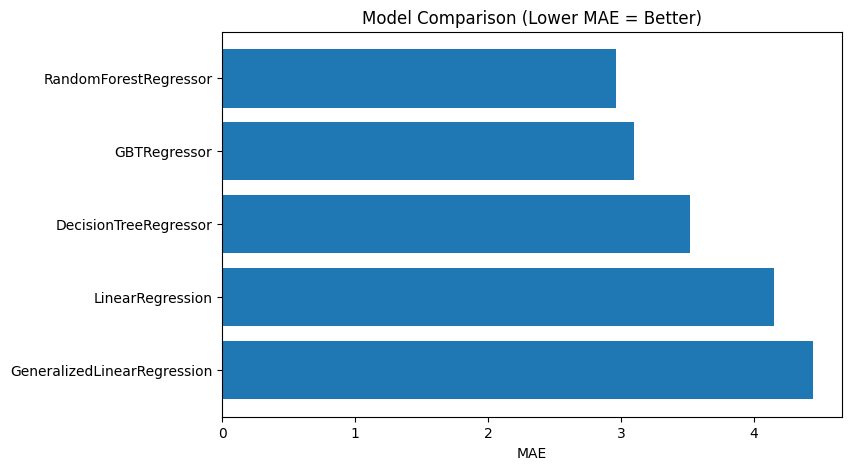

In [31]:
final_pdf = final_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

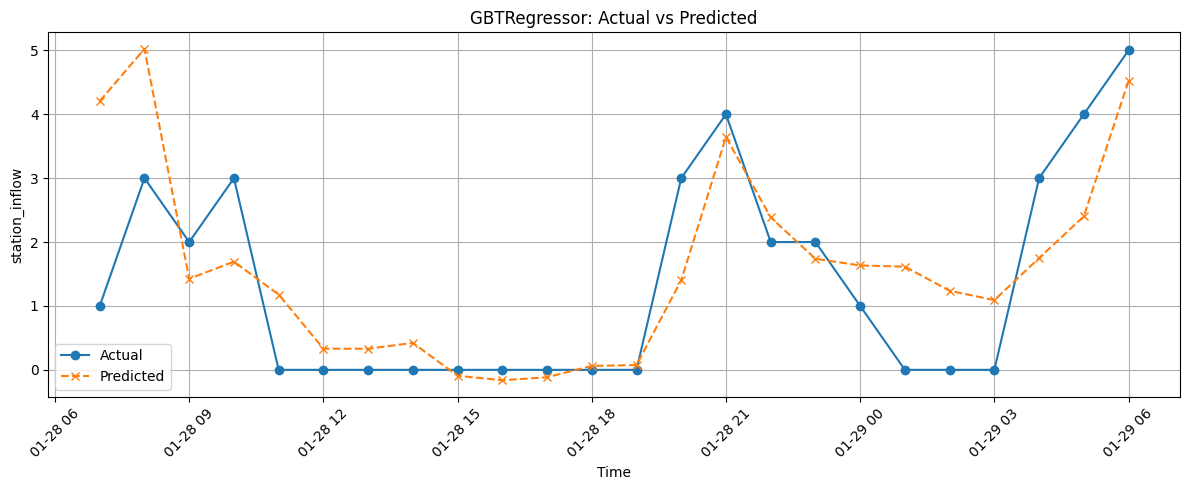

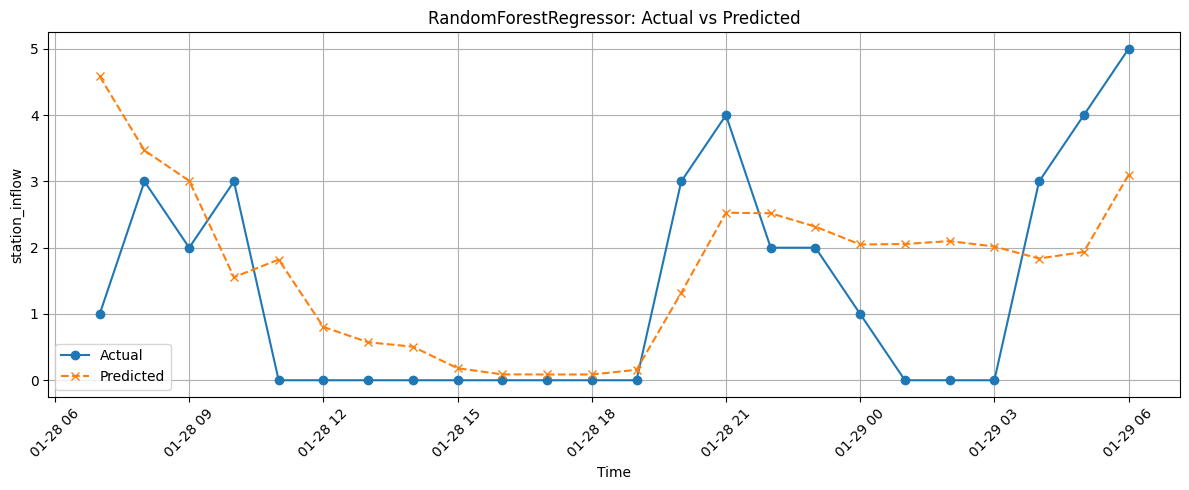

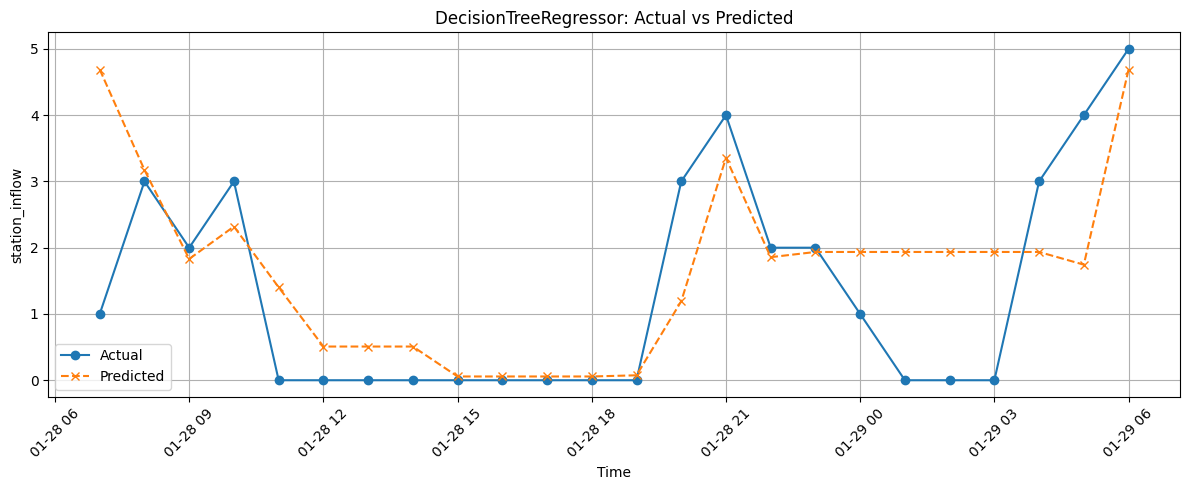

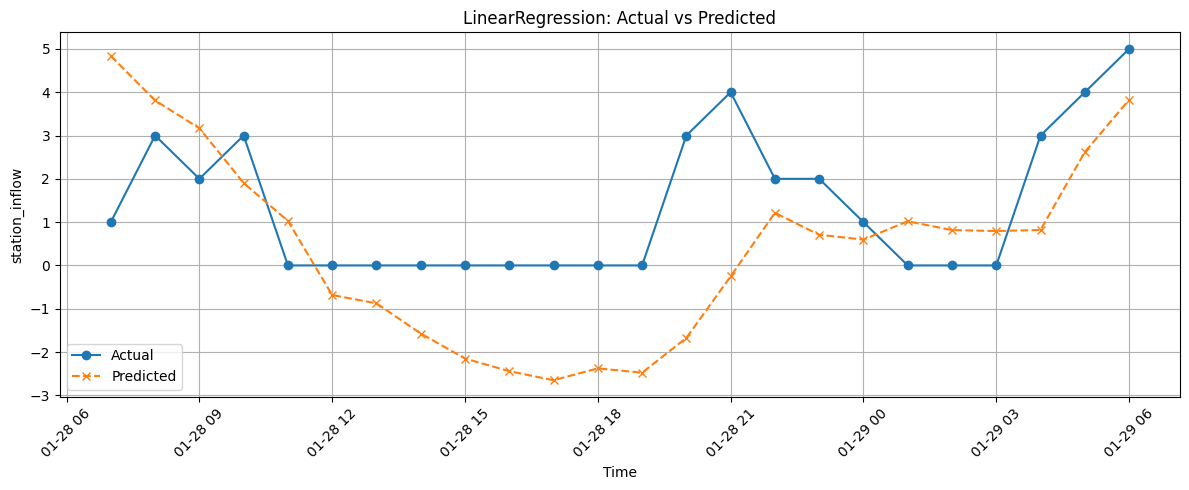

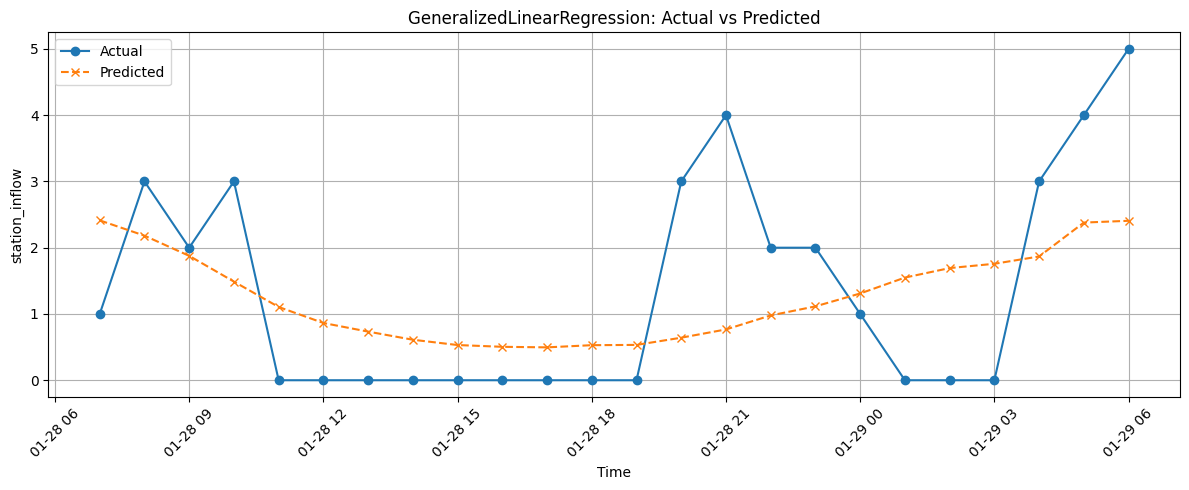

In [32]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

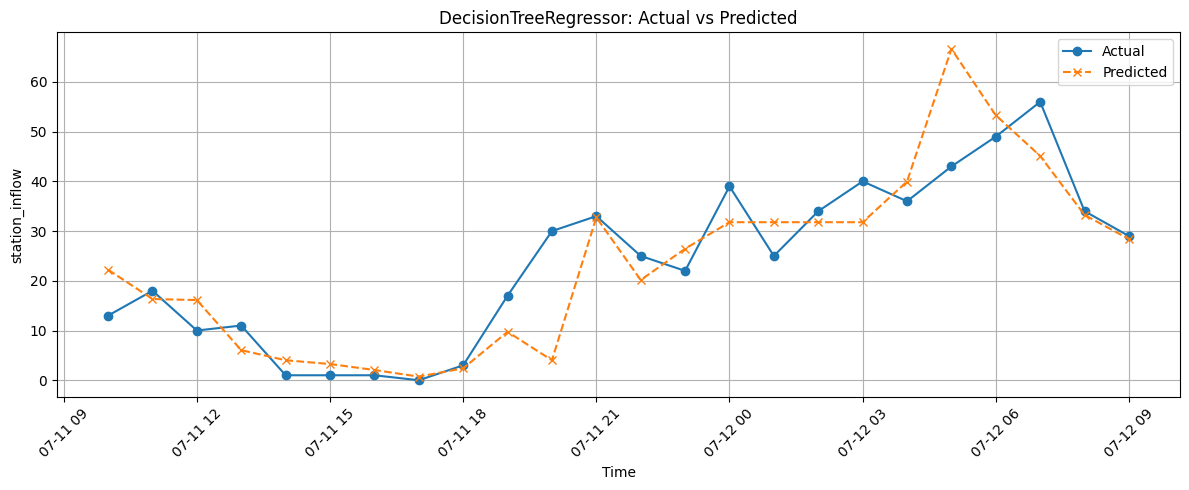

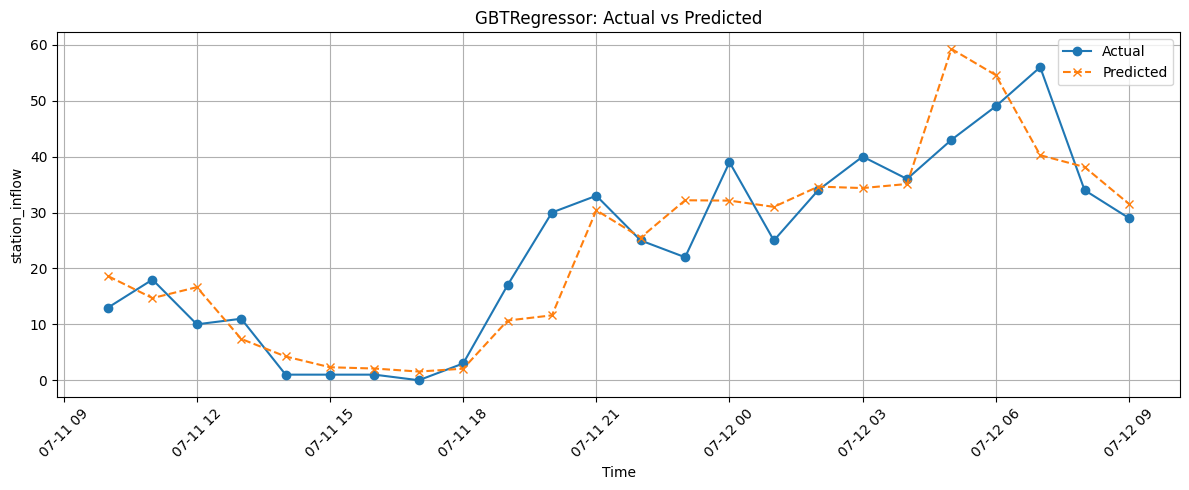

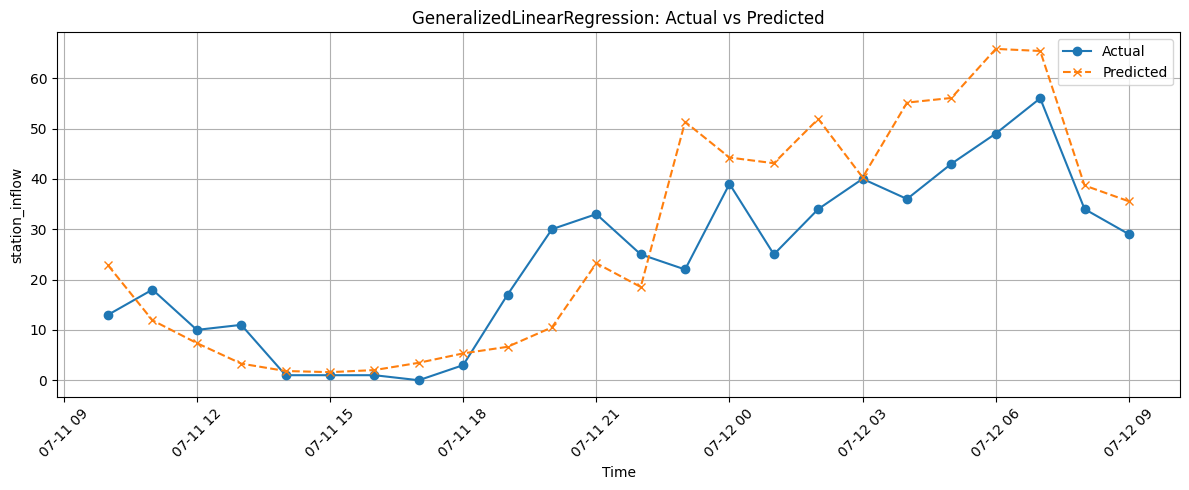

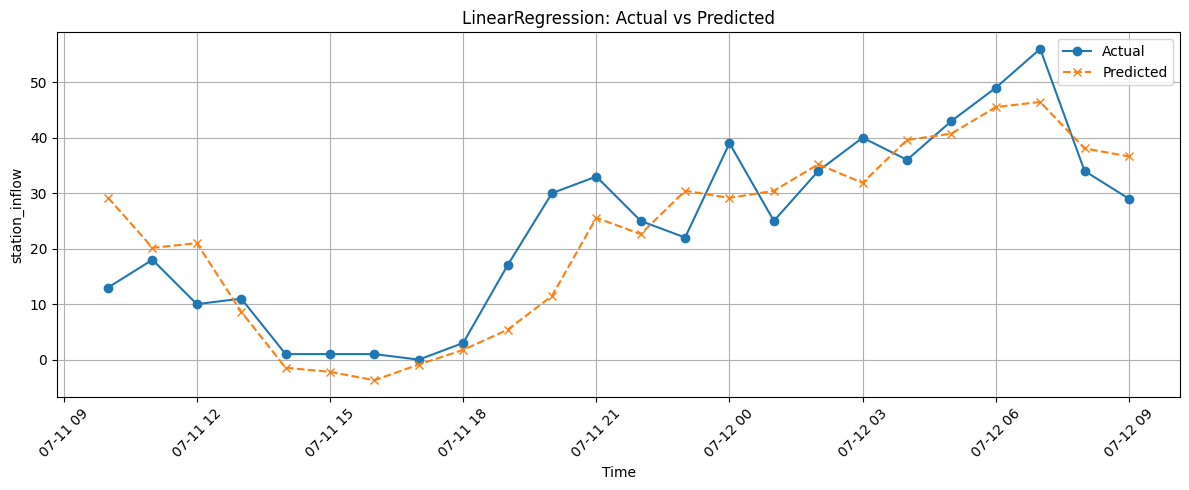

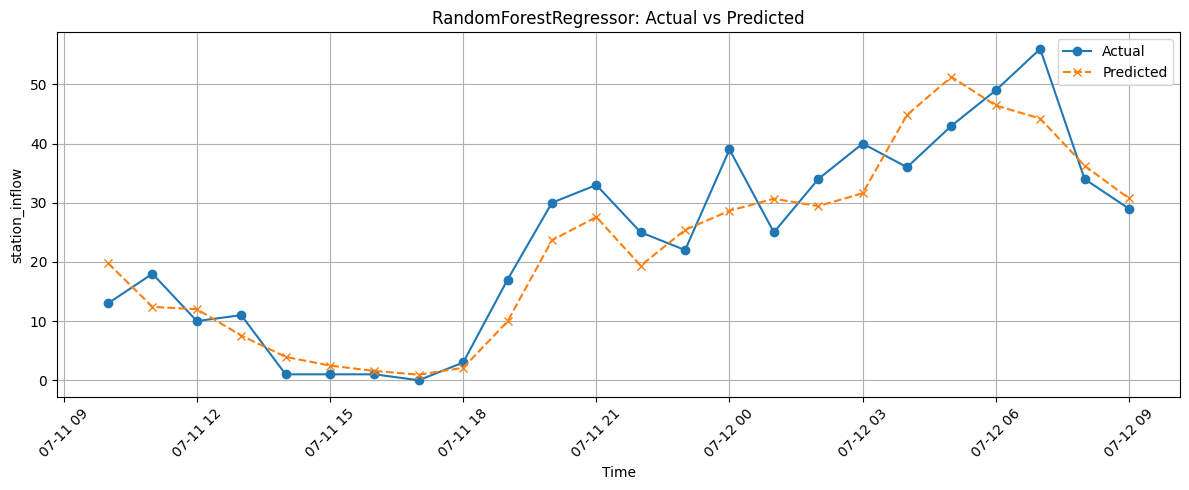

In [33]:
### plot final results 
for result in final_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained INFLOW model

In [34]:
best_inflowModeling_result = min(final_results, key=lambda x: x["mae"])

best_inflow_model_name = best_inflowModeling_result["model_name"]
best_inflow_model = best_inflowModeling_result["fitted_model"]

print("Best model:", best_inflow_model_name)
print("MAE:", best_inflowModeling_result["mae"])
print("RMSE:", best_inflowModeling_result["rmse"])
print("R2:", best_inflowModeling_result["r2"])

Best model: RandomForestRegressor
MAE: 2.961538411310824
RMSE: 4.629681914988058
R2: 0.9109916752994367


In [35]:
save_path = f"outputModels/best_inflow_model_{best_inflow_model_name}"
best_inflow_model.write().overwrite().save(save_path)
print(f"Model saved to: {save_path}")

26/04/18 16:47:46 WARN TaskSetManager: Stage 5323 contains a task of very large size (6236 KiB). The maximum recommended task size is 1000 KiB.


Model saved to: outputModels/best_inflow_model_RandomForestRegressor


## Prediction Target: Outflow
## Output Model: Outflow model

feature importance

In [36]:
ALL_COLUMNS = ['ts_hour', 'station_inflow', 'station_outflow', 'station_netflow', 'radius100m_inflow_lag1', 'radius100m_outflow_lag1', 'radius100m_inflow_lag12', 'radius100m_outflow_lag12', 'radius100m_inflow_rollmean6', 'radius100m_outflow_rollmean6', 'radius100m_inflow_rollmean12', 'radius100m_outflow_rollmean12', 'radius100m_inflow_rollsum6', 'radius100m_outflow_rollsum6', 'radius100m_inflow_rollsum12', 'radius100m_outflow_rollsum12', 'radius200m_inflow_lag1', 'radius200m_outflow_lag1', 'radius200m_inflow_lag12', 'radius200m_outflow_lag12', 'radius200m_inflow_rollmean6', 'radius200m_outflow_rollmean6', 'radius200m_inflow_rollmean12', 'radius200m_outflow_rollmean12', 'radius200m_inflow_rollsum6', 'radius200m_outflow_rollsum6', 'radius200m_inflow_rollsum12', 'radius200m_outflow_rollsum12', 'radius500m_inflow_lag1', 'radius500m_outflow_lag1', 'radius500m_inflow_lag12', 'radius500m_outflow_lag12', 'radius500m_inflow_rollmean6', 'radius500m_outflow_rollmean6', 'radius500m_inflow_rollmean12', 'radius500m_outflow_rollmean12', 'radius500m_inflow_rollsum6', 'radius500m_outflow_rollsum6', 'radius500m_inflow_rollsum12', 'radius500m_outflow_rollsum12', 'temp', 'precip', 'station_inflow_lag1', 'station_outflow_lag1', 'station_inflow_lag12', 'station_outflow_lag12', 'precip_rollmean3', 'station_inflow_rollmean6', 'station_outflow_rollmean6', 'station_inflow_rollmean12', 'station_outflow_rollmean12', 'precip_rollsum3', 'station_inflow_rollsum6', 'station_outflow_rollsum6', 'station_inflow_rollsum12', 'station_outflow_rollsum12', 'temp_bin', 'dow', 'is_weekday', 'hod', 'moy', 'dow_cos', 'hod_cos', 'moy_cos']

TIME_COL = "ts_hour"
TARGET_COL = "station_outflow"   # change to station_outflow or station_netflow as needed

# features to exclude from predictors
BASE_EXCLUDE = [TIME_COL, "station_inflow", "station_outflow", "station_netflow"]

# categorical columns detected from your schema preview
CATEGORICAL_COLS = ["temp_bin"]

# boolean columns
BOOLEAN_COLS = ["is_weekday"]

# numeric columns inferred from your schema preview
NUMERIC_COLS = [c for c in ALL_COLUMNS if c not in BASE_EXCLUDE + CATEGORICAL_COLS + BOOLEAN_COLS]

print("Target:", TARGET_COL)
print("Numeric feature count:", len(NUMERIC_COLS))
print("Categorical feature count:", len(CATEGORICAL_COLS))
print("Boolean feature count:", len(BOOLEAN_COLS))

Target: station_outflow
Numeric feature count: 58
Categorical feature count: 1
Boolean feature count: 1


In [37]:
# fill numeric nulls with 0 for a stable exploratory screen
fill_map = {c: 0.0 for c in NUMERIC_COLS}
fill_map.update({c: 0 for c in BOOLEAN_COLS})

screen_df = gold_0001_df.fillna(fill_map)

# string index + one-hot encode temp_bin
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in CATEGORICAL_COLS]

screen_feature_inputs = NUMERIC_COLS + BOOLEAN_COLS + [f"{c}_ohe" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=screen_feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

screen_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
screen_model = screen_pipe.fit(screen_df)
screen_ready = screen_model.transform(screen_df).select(TIME_COL, TARGET_COL, "features_raw", "features_scaled")
print("Exploratory screening rows:", screen_ready.count())

# helper to expand feature names after OHE
def get_feature_names_from_pipeline_model(pipeline_model, numeric_cols, boolean_cols, categorical_cols):
    feature_names = list(numeric_cols) + list(boolean_cols)
    for c in categorical_cols:
        idx_model = next(s for s in pipeline_model.stages if hasattr(s, 'getOutputCol') and s.getOutputCol() == f"{c}_idx")
        labels = list(idx_model.labels) + ["__unknown__"]
        drop_last = True  # default behavior of Spark OHE
        usable = labels[:-1] if drop_last and len(labels) > 1 else labels
        feature_names.extend([f"{c}={lab}" for lab in usable])
    return feature_names

screen_feature_names = get_feature_names_from_pipeline_model(screen_model, NUMERIC_COLS, BOOLEAN_COLS, CATEGORICAL_COLS)
len(screen_feature_names), screen_feature_names[:10]

Exploratory screening rows: 24614


(68,
 ['radius100m_inflow_lag1',
  'radius100m_outflow_lag1',
  'radius100m_inflow_lag12',
  'radius100m_outflow_lag12',
  'radius100m_inflow_rollmean6',
  'radius100m_outflow_rollmean6',
  'radius100m_inflow_rollmean12',
  'radius100m_outflow_rollmean12',
  'radius100m_inflow_rollsum6',
  'radius100m_outflow_rollsum6'])

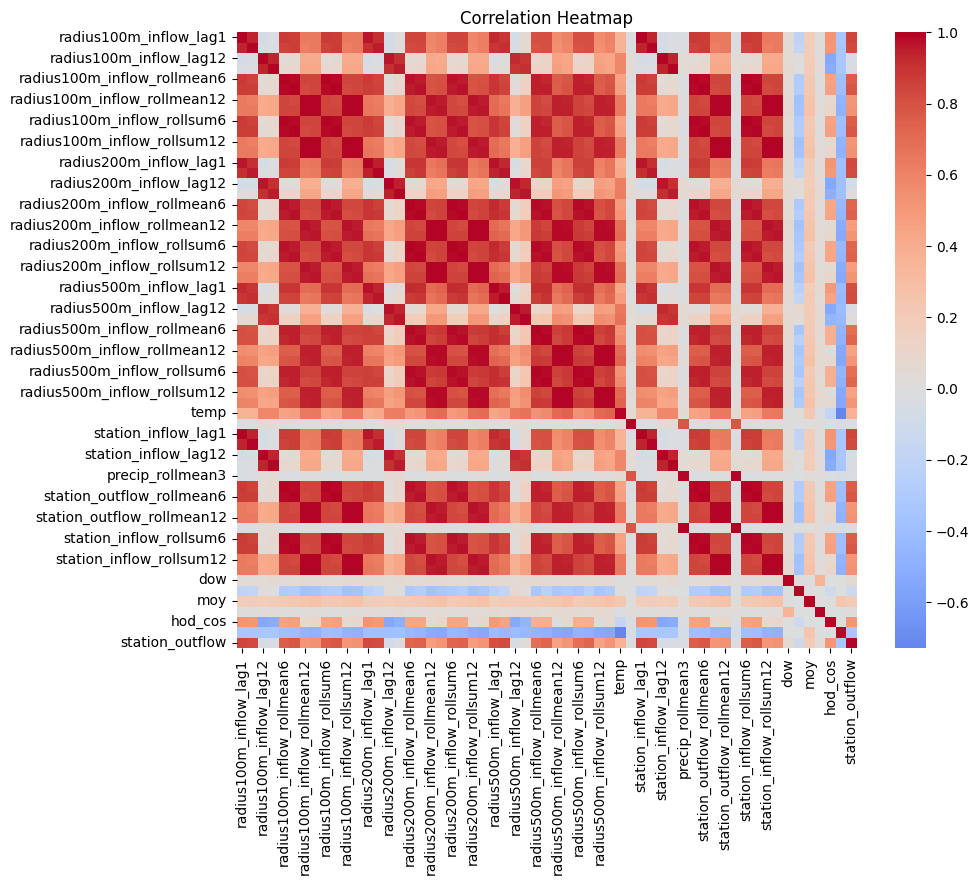

In [38]:
pdf = screen_df.select(NUMERIC_COLS + [TARGET_COL]).toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

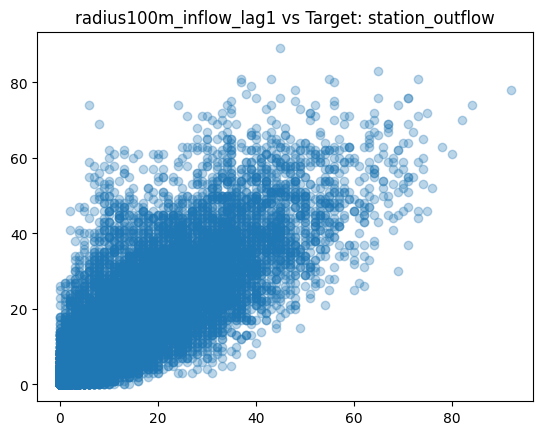

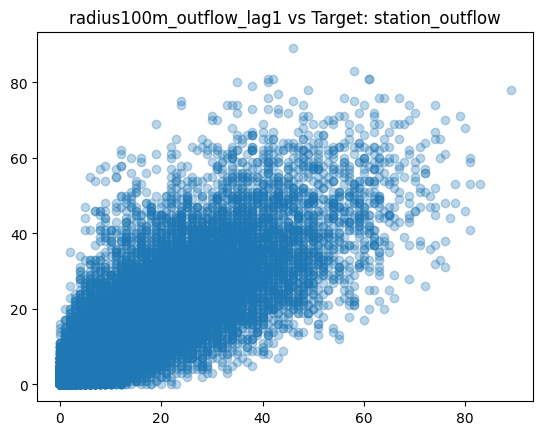

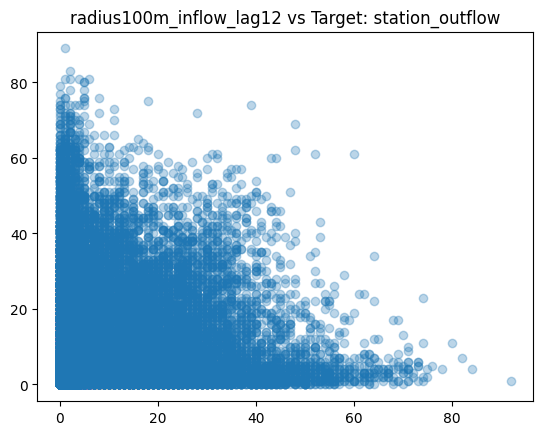

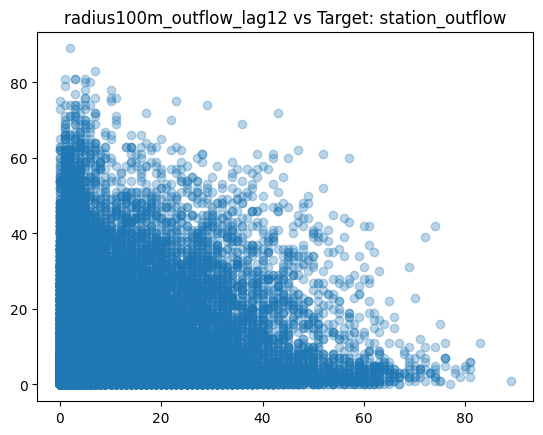

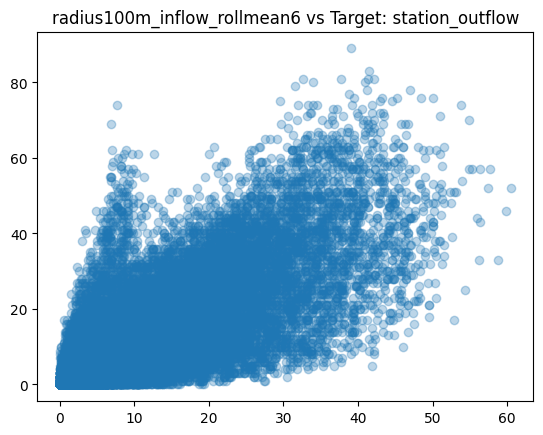

In [39]:
for col in NUMERIC_COLS[:5]:
    plt.scatter(pdf[col], pdf[TARGET_COL], alpha=0.3)
    plt.title(f"{col} vs Target: {TARGET_COL}")
    plt.show()

In [40]:
# exploratory tree-based importance
rf_screen = RandomForestRegressor(
    featuresCol="features_raw",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    numTrees=80,
    maxDepth=8,
    seed=42
)
rf_screen_model = rf_screen.fit(screen_ready)

rf_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "importance": list(rf_screen_model.featureImportances.toArray())
}).sort_values("importance", ascending=False)

rf_importance_pdf.head(20)

26/04/18 16:48:04 WARN DAGScheduler: Broadcasting large task binary with size 1191.3 KiB
26/04/18 16:48:07 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/18 16:48:12 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


,feature,importance
25,radius500m_outflow_lag1,0.305302
13,radius200m_outflow_lag1,0.136052
0,radius100m_inflow_lag1,0.120465
38,station_inflow_lag1,0.055642
1,radius100m_outflow_lag1,0.054923
53,hod,0.039996
56,hod_cos,0.037160
12,radius200m_inflow_lag1,0.036734
39,station_outflow_lag1,0.034960
49,station_outflow_rollsum6,0.026930


In [41]:
# exploratory linear importance using standardized features
lr_screen = LinearRegression(
    featuresCol="features_scaled",
    labelCol=TARGET_COL,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)
lr_screen_model = lr_screen.fit(screen_ready)

lr_importance_pdf = pd.DataFrame({
    "feature": screen_feature_names,
    "coefficient": list(lr_screen_model.coefficients.toArray())
})
lr_importance_pdf["abs_coefficient"] = lr_importance_pdf["coefficient"].abs()
lr_importance_pdf = lr_importance_pdf.sort_values("abs_coefficient", ascending=False)

lr_importance_pdf.head(20)

26/04/18 16:48:18 WARN Instrumentation: [42ee02dd] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:48:19 WARN Instrumentation: [42ee02dd] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,8.795311,8.795311
31,radius500m_outflow_rollmean12,8.720410,8.720410
30,radius500m_inflow_rollmean12,-7.813471,7.813471
34,radius500m_inflow_rollsum12,-7.751781,7.751781
25,radius500m_outflow_lag1,6.485529,6.485529
29,radius500m_outflow_rollmean6,-5.519813,5.519813
33,radius500m_outflow_rollsum6,-5.507133,5.507133
9,radius100m_outflow_rollsum6,4.395671,4.395671
49,station_outflow_rollsum6,4.395671,4.395671
44,station_outflow_rollmean6,4.383599,4.383599


In [42]:
# choose candidate features from the exploratory screen
TOP_N_TREE = 25
TOP_N_LINEAR = 25

tree_top = rf_importance_pdf.head(TOP_N_TREE)["feature"].tolist()
linear_top = lr_importance_pdf.head(TOP_N_LINEAR)["feature"].tolist()

screen_top_union = sorted(set(tree_top) | set(linear_top))
print("Union of shortlisted features:", len(screen_top_union))
screen_top_union[:20]

Union of shortlisted features: 36


['dow_cos',
 'hod',
 'hod_cos',
 'radius100m_inflow_lag1',
 'radius100m_inflow_rollmean6',
 'radius100m_outflow_lag1',
 'radius100m_outflow_rollmean12',
 'radius100m_outflow_rollmean6',
 'radius100m_outflow_rollsum12',
 'radius100m_outflow_rollsum6',
 'radius200m_inflow_lag1',
 'radius200m_inflow_lag12',
 'radius200m_inflow_rollmean12',
 'radius200m_inflow_rollsum12',
 'radius200m_inflow_rollsum6',
 'radius200m_outflow_lag1',
 'radius200m_outflow_rollmean12',
 'radius200m_outflow_rollmean6',
 'radius200m_outflow_rollsum12',
 'radius200m_outflow_rollsum6']

In [43]:
## set USE_SCREENED_FEATURES to True if want to use reduced feature set
USE_SCREENED_FEATURES = False

if USE_SCREENED_FEATURES:
    # screen_top_union contains expanded names after OHE, so for actual assembly we keep all original columns
    # and later inspect importance again on the training-only data
    print("Using original columns but screened results only as guidance.")

MODEL_NUMERIC_COLS = NUMERIC_COLS
MODEL_BOOLEAN_COLS = BOOLEAN_COLS
MODEL_CATEGORICAL_COLS = CATEGORICAL_COLS

fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

train_df = train_df.fillna(fill_map)
val_df = val_df.fillna(fill_map)
test_df = test_df.fillna(fill_map)

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in MODEL_CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) for c in MODEL_CATEGORICAL_COLS]

feature_inputs = MODEL_NUMERIC_COLS + MODEL_BOOLEAN_COLS + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_inputs, outputCol="features_raw", handleInvalid="keep")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=False, withStd=True)

prep_pipe = Pipeline(stages=indexers + encoders + [assembler, scaler])
prep_model = prep_pipe.fit(train_df)

train_ready = prep_model.transform(train_df)
val_ready = prep_model.transform(val_df)
test_ready = prep_model.transform(test_df)

model_feature_names = get_feature_names_from_pipeline_model(prep_model, MODEL_NUMERIC_COLS, MODEL_BOOLEAN_COLS, MODEL_CATEGORICAL_COLS)
print("Prepared feature count:", len(model_feature_names))

Prepared feature count: 68


In [44]:
evaluator_specs = ["rmse", "mae", "r2"]

def evaluate_predictions(pred_df, label_col=TARGET_COL):
    out = {}
    for metric in evaluator_specs:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
        out[metric] = ev.evaluate(pred_df)
    return out

def fit_and_evaluate(model_name, estimator, train_data, eval_data, features_col):
    fitted = estimator.fit(train_data)
    pred = fitted.transform(eval_data)
    metrics = evaluate_predictions(pred, TARGET_COL)
    return {
        "model_name": model_name,
        "features_col": features_col,
        "fitted_model": fitted,
        "predictions": pred,
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "r2": metrics["r2"],
    }

def extract_tree_importance(model, feature_names):
    if hasattr(model, "featureImportances"):
        return pd.DataFrame({
            "feature": feature_names,
            "importance": list(model.featureImportances.toArray())
        }).sort_values("importance", ascending=False)
    return None

def extract_linear_importance(model, feature_names):
    if hasattr(model, "coefficients"):
        pdf = pd.DataFrame({
            "feature": feature_names,
            "coefficient": list(model.coefficients.toArray())
        })
        pdf["abs_coefficient"] = pdf["coefficient"].abs()
        return pdf.sort_values("abs_coefficient", ascending=False)
    return None

#### 11. First-round baseline training

Design choice:
- tree models use `features_raw`
- linear models use `features_scaled`
- Poisson GLR assumes a non-negative target, so use it mainly for `station_inflow` or `station_outflow`

Model Training - To Try All types of Time Series Regression supported by Spark

In [45]:
baseline_models = {
    "GBTRegressor": GBTRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        maxDepth=5,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=1.0,
        seed=42
    ),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        numTrees=100,
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        featuresCol="features_raw",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxDepth=8,
        maxBins=32,
        seed=42
    ),
    "LinearRegression": LinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.1,
        elasticNetParam=0.0
    ),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(
        featuresCol="features_scaled",
        labelCol=TARGET_COL,
        predictionCol="prediction",
        family="poisson",
        link="log",
        maxIter=50,
        regParam=0.0
    )
}

In [46]:
baseline_results = []

for model_name, estimator in baseline_models.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        print(f"Skipping {model_name} because Poisson GLR is not suitable for negative netflow targets.")
        continue

    features_col = estimator.getFeaturesCol()
    result = fit_and_evaluate(model_name, estimator, train_ready, val_ready, features_col)
    baseline_results.append(result)
    print(model_name, {k: result[k] for k in ['rmse', 'mae', 'r2']})

baseline_metrics_pdf = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in baseline_results
]).sort_values("rmse")

baseline_metrics_pdf

GBTRegressor {'rmse': 5.202695610524233, 'mae': 3.1871145901953515, 'r2': 0.8715592625120865}


26/04/18 16:49:13 WARN DAGScheduler: Broadcasting large task binary with size 1451.8 KiB
26/04/18 16:49:16 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/18 16:49:20 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/04/18 16:49:24 WARN DAGScheduler: Broadcasting large task binary with size 1153.4 KiB


RandomForestRegressor {'rmse': 5.1804402054652865, 'mae': 3.1851646334320014, 'r2': 0.8726557659379612}


DecisionTreeRegressor {'rmse': 5.837571563021243, 'mae': 3.5500168337285185, 'r2': 0.8382998620849551}
LinearRegression {'rmse': 6.0906319301578415, 'mae': 3.8700444611643015, 'r2': 0.8239764948029834}


26/04/18 16:49:35 WARN Instrumentation: [579b8d6f] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:49:35 WARN Instrumentation: [579b8d6f] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:49:35 WARN Instrumentation: [579b8d6f] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:49:36 WARN Instrumentation: [579b8d6f] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:49:36 WARN Instrumentation: [579b8d6f] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:49:36 WARN Instrumentation: [579b8d6f] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:49:36 WARN Instrumentation: [579b8d6f] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:49:37 WARN Instrumentation: [579b8d6f] Cholesky solv

GeneralizedLinearRegression {'rmse': 6.447797542210908, 'mae': 4.076090911274348, 'r2': 0.8027265045703129}


,model_name,features_col,rmse,mae,r2
1,RandomForestRegressor,features_raw,5.180440,3.185165,0.872656
0,GBTRegressor,features_raw,5.202696,3.187115,0.871559
2,DecisionTreeRegressor,features_raw,5.837572,3.550017,0.838300
3,LinearRegression,features_scaled,6.090632,3.870044,0.823976
4,GeneralizedLinearRegression,features_scaled,6.447798,4.076091,0.802727


#### 12. Training-only feature importance after the baseline round


In [47]:
importance_tables = {}

for r in baseline_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        importance_tables[name] = extract_linear_importance(model, model_feature_names)

list(importance_tables.keys())

['GBTRegressor',
 'RandomForestRegressor',
 'DecisionTreeRegressor',
 'LinearRegression',
 'GeneralizedLinearRegression']

In [48]:
"""inspect top 3 features from all regresssors' importance table"""

print(importance_tables['GBTRegressor'].head(3))
print(importance_tables['RandomForestRegressor'].head(3))
print(importance_tables['DecisionTreeRegressor'].head(3))
print(importance_tables['LinearRegression'].head(3))
print(importance_tables['GeneralizedLinearRegression'].head(3))

                         feature  importance
25       radius500m_outflow_lag1    0.274779
53                           hod    0.110618
5   radius100m_outflow_rollmean6    0.086549
                    feature  importance
25  radius500m_outflow_lag1    0.273607
13  radius200m_outflow_lag1    0.157759
0    radius100m_inflow_lag1    0.123591
                    feature  importance
25  radius500m_outflow_lag1    0.603213
12   radius200m_inflow_lag1    0.109508
53                      hod    0.070025
                          feature  coefficient  abs_coefficient
25        radius500m_outflow_lag1     4.944787         4.944787
35   radius500m_outflow_rollsum12     3.602431         3.602431
31  radius500m_outflow_rollmean12     3.578516         3.578516
                          feature  coefficient  abs_coefficient
35   radius500m_outflow_rollsum12     0.539600         0.539600
31  radius500m_outflow_rollmean12     0.529460         0.529460
25        radius500m_outflow_lag1     0.470742      

#### 13. Manual time-aware hyperparameter tuning

Tunes using:
- `train_df` for fitting
- `val_df` for model selection

Which respects chronological order.

In [49]:
param_grids = {
    "GBTRegressor": [
        {"maxIter": 50, "maxDepth": 4, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 5, "stepSize": 0.05, "maxBins": 32},
        {"maxIter": 100, "maxDepth": 6, "stepSize": 0.1, "maxBins": 32},
    ],
    "RandomForestRegressor": [
        {"numTrees": 80, "maxDepth": 6, "maxBins": 32},
        {"numTrees": 120, "maxDepth": 8, "maxBins": 32},
        {"numTrees": 150, "maxDepth": 10, "maxBins": 64},
    ],
    "DecisionTreeRegressor": [
        {"maxDepth": 5, "maxBins": 32},
        {"maxDepth": 8, "maxBins": 32},
        {"maxDepth": 10, "maxBins": 64},
    ],
    "LinearRegression": [
        {"maxIter": 100, "regParam": 0.0, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.0},
        {"maxIter": 100, "regParam": 0.1, "elasticNetParam": 0.5},
        {"maxIter": 150, "regParam": 0.2, "elasticNetParam": 1.0},
    ],
    "GeneralizedLinearRegression": [
        {"maxIter": 50, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.0},
        {"maxIter": 100, "regParam": 0.1},
    ],
}


def build_estimator(model_name, params):
    if model_name == "GBTRegressor":
        return GBTRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, subsamplingRate=1.0, **params
        )
    if model_name == "RandomForestRegressor":
        return RandomForestRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "DecisionTreeRegressor":
        return DecisionTreeRegressor(
            featuresCol="features_raw", labelCol=TARGET_COL, predictionCol="prediction",
            seed=42, **params
        )
    if model_name == "LinearRegression":
        return LinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            **params
        )
    if model_name == "GeneralizedLinearRegression":
        return GeneralizedLinearRegression(
            featuresCol="features_scaled", labelCol=TARGET_COL, predictionCol="prediction",
            family="poisson", link="log", **params
        )
    raise ValueError("Unknown model")

In [50]:
tuning_rows = []

for model_name, grid in param_grids.items():
    if model_name == "GeneralizedLinearRegression" and TARGET_COL == "station_netflow":
        continue

    print(f"\nTuning {model_name}")
    for params in grid:
        est = build_estimator(model_name, params)
        fitted = est.fit(train_ready)
        pred = fitted.transform(val_ready)
        metrics = evaluate_predictions(pred, TARGET_COL)

        row = {
            "model_name": model_name,
            "params_json": json.dumps(params, sort_keys=True),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
        }
        tuning_rows.append(row)
        print(row)

tuning_pdf = pd.DataFrame(tuning_rows).sort_values(["model_name", "rmse"])
tuning_pdf


Tuning GBTRegressor


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 4, "maxIter": 50, "stepSize": 0.05}', 'rmse': 5.5147733223720685, 'mae': 3.466895704058007, 'r2': 0.855688384944445}


{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 5, "maxIter": 100, "stepSize": 0.05}', 'rmse': 5.238556120432409, 'mae': 3.227190133077417, 'r2': 0.8697825589132238}


26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1002.1 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1004.5 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1005.0 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1005.5 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1006.5 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1008.2 KiB
26/04/18 16:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1011.7 KiB
26/04/18 16:51:36 WARN DAGScheduler: Broadcasting large task binary with size 1014.5 KiB
26/04/18 16:51:36 WARN DAGScheduler: Broadcasting large task binary with size 1015.0 KiB
26/04/18 16:51:36 WARN DAGScheduler: Broadcasting large task binary with size 1016.0 KiB
26/04/18 16:51:36 WARN DAGScheduler: Broadcasting large task binary with size 1016.7 KiB
26/04/18 16:51:36 WAR

{'model_name': 'GBTRegressor', 'params_json': '{"maxBins": 32, "maxDepth": 6, "maxIter": 100, "stepSize": 0.1}', 'rmse': 5.266311045003321, 'mae': 3.1779508643103545, 'r2': 0.8683990671701577}

Tuning RandomForestRegressor


...

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 50, "regParam": 0.0}', 'rmse': 6.447797542210908, 'mae': 4.076090911274348, 'r2': 0.8027265045703129}


26/04/18 16:54:41 WARN Instrumentation: [07e4d3ba] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:54:42 WARN Instrumentation: [07e4d3ba] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:54:42 WARN Instrumentation: [07e4d3ba] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:54:43 WARN Instrumentation: [07e4d3ba] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:54:43 WARN Instrumentation: [07e4d3ba] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:54:44 WARN Instrumentation: [07e4d3ba] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:54:44 WARN Instrumentation: [07e4d3ba] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:54:44 WARN Instrumentation: [07e4d3ba] Cholesky solv

{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.0}', 'rmse': 6.443043048433776, 'mae': 4.073657523094064, 'r2': 0.8030173293958671}


{'model_name': 'GeneralizedLinearRegression', 'params_json': '{"maxIter": 100, "regParam": 0.1}', 'rmse': 6.7637030152647535, 'mae': 4.321677810504354, 'r2': 0.7829223980968957}


,model_name,params_json,rmse,mae,r2
7,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.837572,3.550017,0.838300
8,DecisionTreeRegressor,"{""maxBins"": 64, ""maxDepth"": 10}",5.860108,3.510539,0.837049
6,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 5}",6.479462,4.032488,0.800784
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.238556,3.227190,0.869783
2,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 6, ""maxIter"": 100,...",5.266311,3.177951,0.868399
0,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 4, ""maxIter"": 50, ...",5.514773,3.466896,0.855688
14,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",6.443043,4.073658,0.803017
13,GeneralizedLinearRegression,"{""maxIter"": 50, ""regParam"": 0.0}",6.447798,4.076091,0.802727
15,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.1}",6.763703,4.321678,0.782922
9,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.074361,3.871377,0.824916


In [51]:
best_params_pdf = tuning_pdf.sort_values("rmse").groupby("model_name", as_index=False).first()
best_params_pdf

,model_name,params_json,rmse,mae,r2
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",5.837572,3.550017,0.838300
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.238556,3.227190,0.869783
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",6.443043,4.073658,0.803017
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",6.074361,3.871377,0.824916
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",4.899923,3.006874,0.886074


#### 14. Retrain with best parameters on the full 80% training window, then evaluate on the untouched 20% test set

In [52]:
train_full_ready = prep_model.transform(train_full_df.fillna(fill_map))
test_ready = prep_model.transform(test_df.fillna(fill_map))

final_results_outflow = []

for _, row in best_params_pdf.iterrows():
    model_name = row["model_name"]
    params = json.loads(row["params_json"])
    final_est = build_estimator(model_name, params)
    final_model = final_est.fit(train_full_ready)
    final_pred = final_model.transform(test_ready)
    final_metrics = evaluate_predictions(final_pred, TARGET_COL)

    final_results_outflow.append({
        "model_name": model_name,
        "params_json": json.dumps(params, sort_keys=True),
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"],
        "fitted_model": final_model,
        "predictions": final_pred,
    })

final_metrics_pdf_outflow = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["fitted_model", "predictions"]}
    for r in final_results_outflow
]).sort_values("rmse")

final_metrics_pdf_outflow

26/04/18 16:56:38 WARN Instrumentation: [dea08c88] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:56:38 WARN Instrumentation: [dea08c88] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:56:38 WARN Instrumentation: [dea08c88] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:56:39 WARN Instrumentation: [dea08c88] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:56:39 WARN Instrumentation: [dea08c88] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:56:40 WARN Instrumentation: [dea08c88] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/04/18 16:56:40 WARN Instrumentation: [dea08c88] regParam is zero, which might cause numerical instability and overfitting.
26/04/18 16:56:40 WARN Instrumentation: [dea08c88] Cholesky solv

,model_name,params_json,rmse,mae,r2
1,GBTRegressor,"{""maxBins"": 32, ""maxDepth"": 5, ""maxIter"": 100,...",5.369103,3.517721,0.899328
4,RandomForestRegressor,"{""maxBins"": 64, ""maxDepth"": 10, ""numTrees"": 150}",5.449209,3.519509,0.896302
0,DecisionTreeRegressor,"{""maxBins"": 32, ""maxDepth"": 8}",6.242477,4.007616,0.863913
3,LinearRegression,"{""elasticNetParam"": 0.0, ""maxIter"": 100, ""regP...",7.303645,4.837755,0.813713
2,GeneralizedLinearRegression,"{""maxIter"": 100, ""regParam"": 0.0}",9.195422,5.322452,0.704711


In [53]:
"""getting the feature importance from the final models"""
final_importance_tables = {}

for r in final_results:
    name = r["model_name"]
    model = r["fitted_model"]
    if name in {"GBTRegressor", "RandomForestRegressor", "DecisionTreeRegressor"}:
        final_importance_tables[name] = extract_tree_importance(model, model_feature_names)
    elif name in {"LinearRegression", "GeneralizedLinearRegression"}:
        final_importance_tables[name] = extract_linear_importance(model, model_feature_names)

for name, pdf in final_importance_tables.items():
    print("\n", name)
    display(pdf.head(15))


 DecisionTreeRegressor


,feature,importance
25,radius500m_outflow_lag1,0.615588
24,radius500m_inflow_lag1,0.111059
53,hod,0.047907
12,radius200m_inflow_lag1,0.041175
30,radius500m_inflow_rollmean12,0.037952
4,radius100m_inflow_rollmean6,0.035797
6,radius100m_inflow_rollmean12,0.030763
0,radius100m_inflow_lag1,0.026658
56,hod_cos,0.016930
13,radius200m_outflow_lag1,0.008913



 GBTRegressor


,feature,importance
25,radius500m_outflow_lag1,0.230431
4,radius100m_inflow_rollmean6,0.104012
53,hod,0.079401
24,radius500m_inflow_lag1,0.078995
56,hod_cos,0.070040
6,radius100m_inflow_rollmean12,0.046388
30,radius500m_inflow_rollmean12,0.044624
0,radius100m_inflow_lag1,0.033957
12,radius200m_inflow_lag1,0.029447
55,dow_cos,0.029148



 GeneralizedLinearRegression


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,0.608981,0.608981
31,radius500m_outflow_rollmean12,0.599400,0.599400
56,hod_cos,0.488928,0.488928
25,radius500m_outflow_lag1,0.429750,0.429750
28,radius500m_inflow_rollmean6,-0.408064,0.408064
32,radius500m_inflow_rollsum6,-0.406723,0.406723
26,radius500m_inflow_lag12,0.298961,0.298961
30,radius500m_inflow_rollmean12,-0.298023,0.298023
34,radius500m_inflow_rollsum12,-0.292329,0.292329
57,moy_cos,-0.253218,0.253218



 LinearRegression


,feature,coefficient,abs_coefficient
35,radius500m_outflow_rollsum12,9.041158,9.041158
31,radius500m_outflow_rollmean12,8.953784,8.953784
30,radius500m_inflow_rollmean12,-7.130979,7.130979
34,radius500m_inflow_rollsum12,-7.065144,7.065144
24,radius500m_inflow_lag1,5.663437,5.663437
29,radius500m_outflow_rollmean6,-4.994579,4.994579
33,radius500m_outflow_rollsum6,-4.976673,4.976673
25,radius500m_outflow_lag1,4.748648,4.748648
27,radius500m_outflow_lag12,-3.162011,3.162011
48,station_inflow_rollsum6,2.776738,2.776738



 RandomForestRegressor


,feature,importance
25,radius500m_outflow_lag1,0.201057
0,radius100m_inflow_lag1,0.161694
13,radius200m_outflow_lag1,0.157775
38,station_inflow_lag1,0.070059
12,radius200m_inflow_lag1,0.051318
1,radius100m_outflow_lag1,0.039790
24,radius500m_inflow_lag1,0.036200
53,hod,0.035247
56,hod_cos,0.033934
4,radius100m_inflow_rollmean6,0.025835


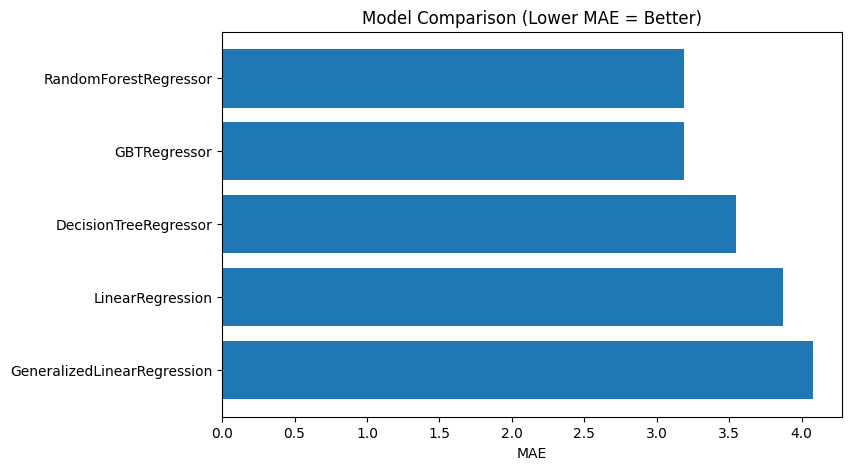

In [54]:
baseline_pdf = baseline_metrics_pdf.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(baseline_pdf["model_name"], baseline_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

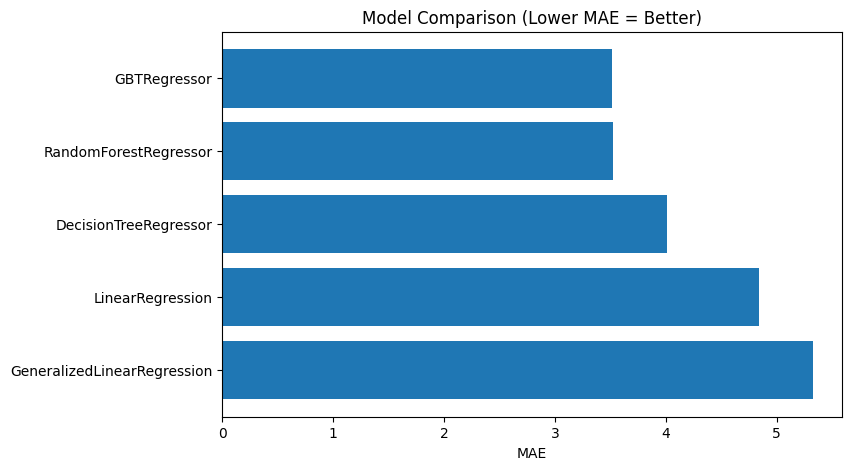

In [55]:
final_pdf = final_metrics_pdf_outflow.sort_values("mae")

plt.figure(figsize=(8,5))
plt.barh(final_pdf["model_name"], final_pdf["mae"])
plt.xlabel("MAE")
plt.title("Model Comparison (Lower MAE = Better)")
plt.gca().invert_yaxis()
plt.show()

##### 15. plot 

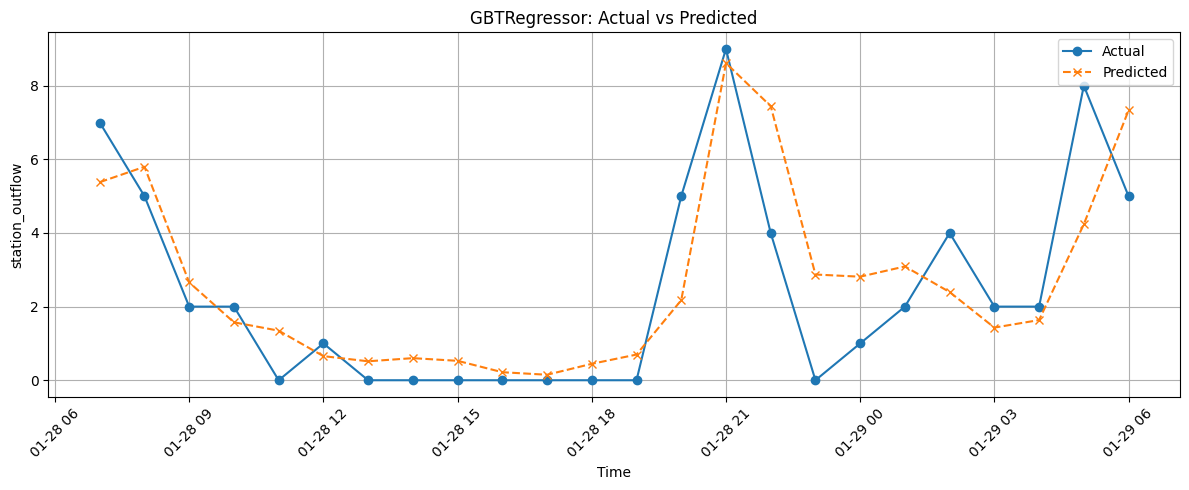

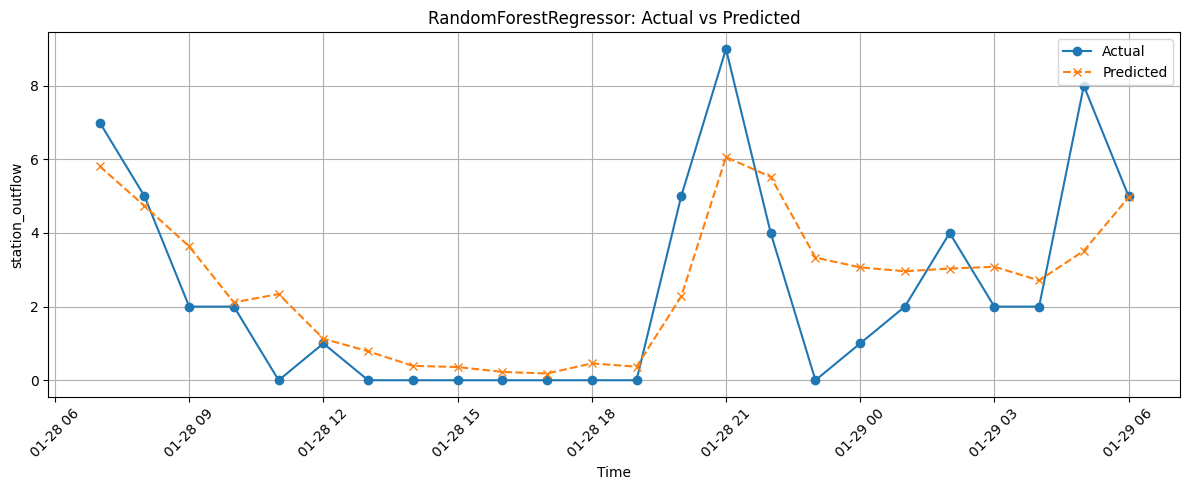

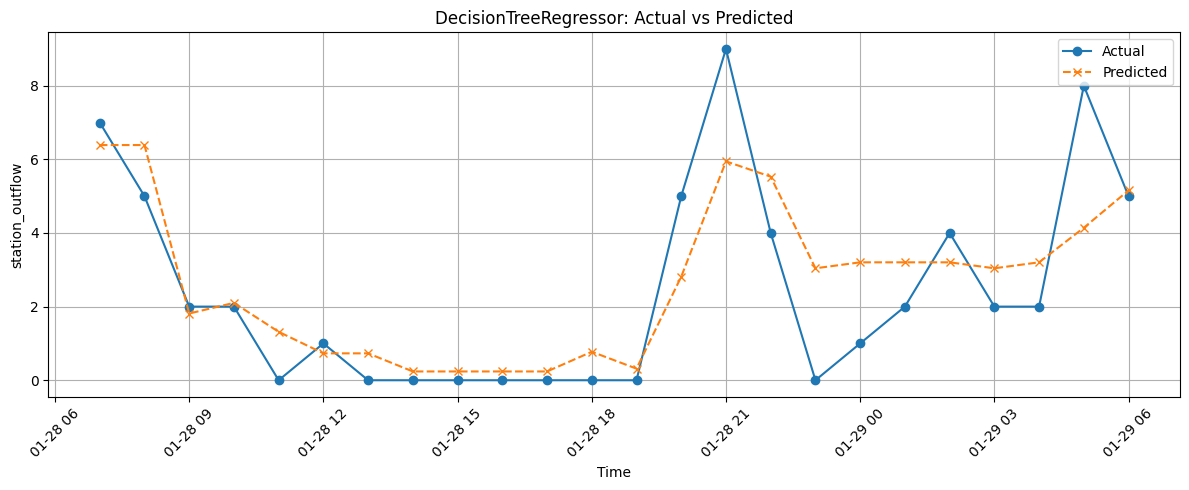

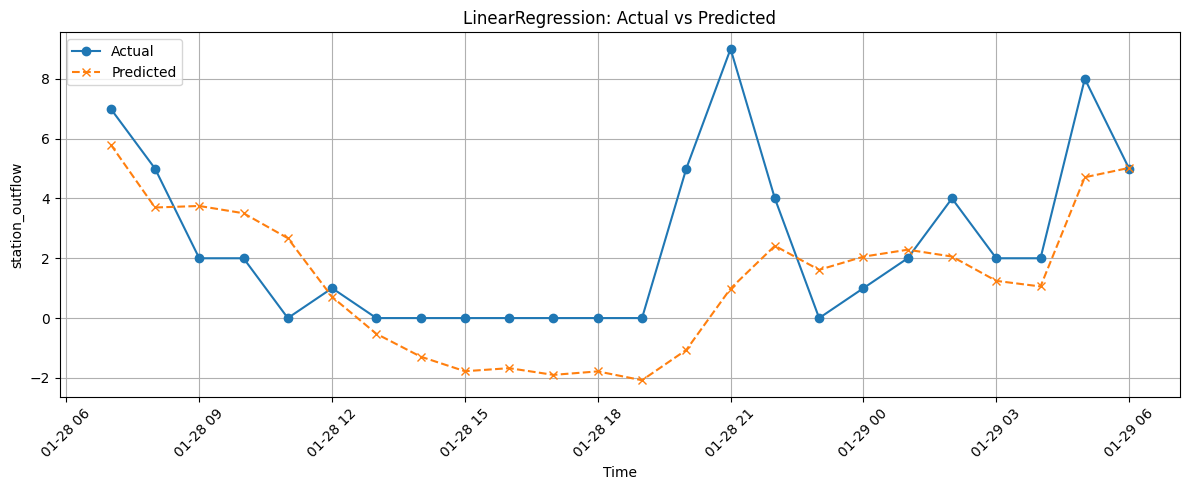

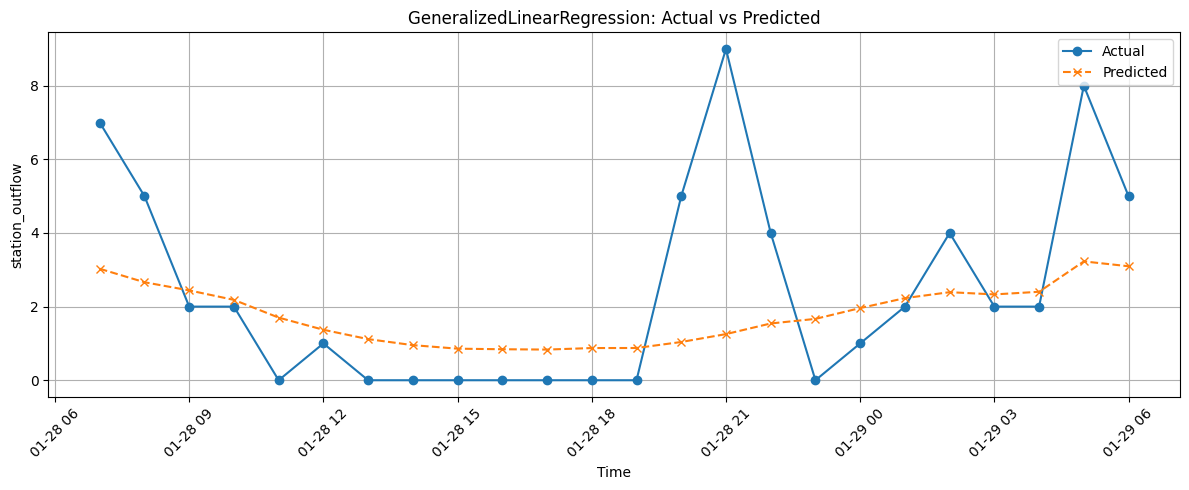

In [56]:
### plot baseline results 
for result in baseline_results:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

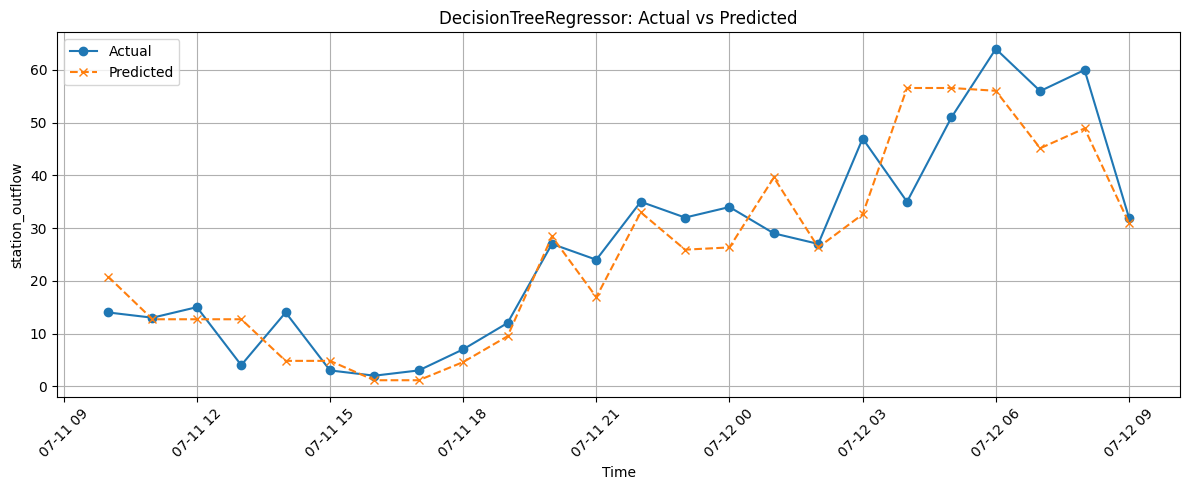

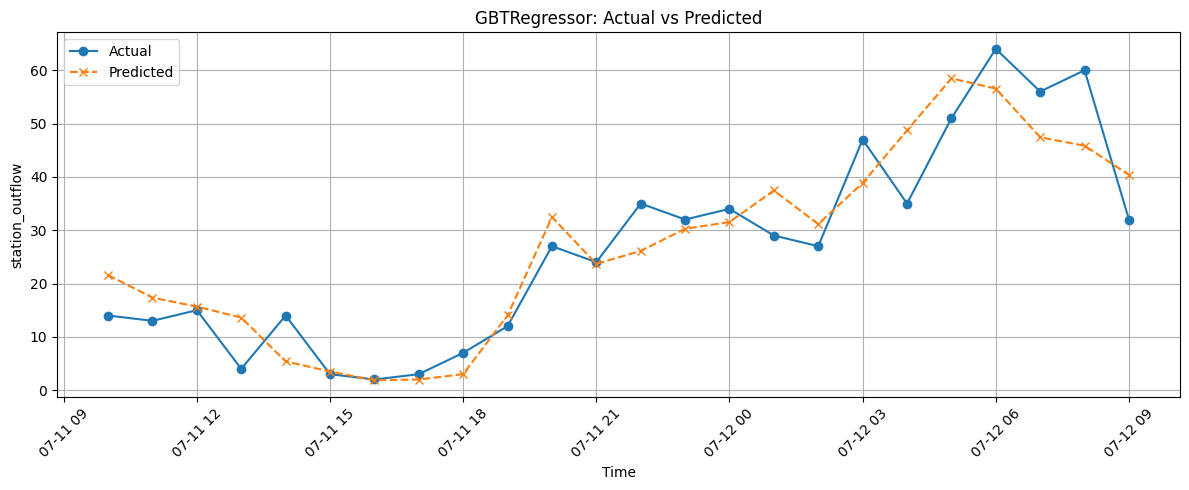

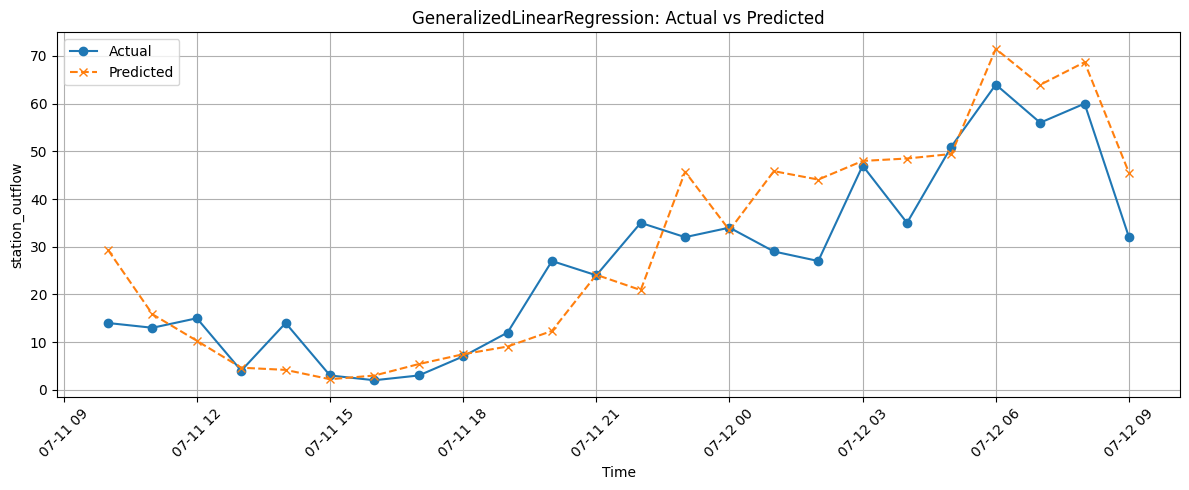

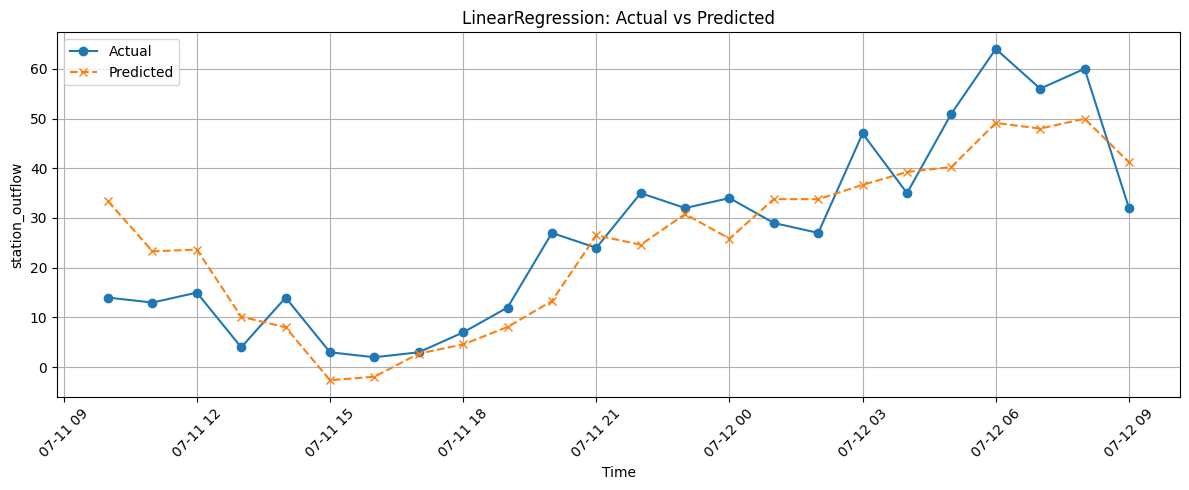

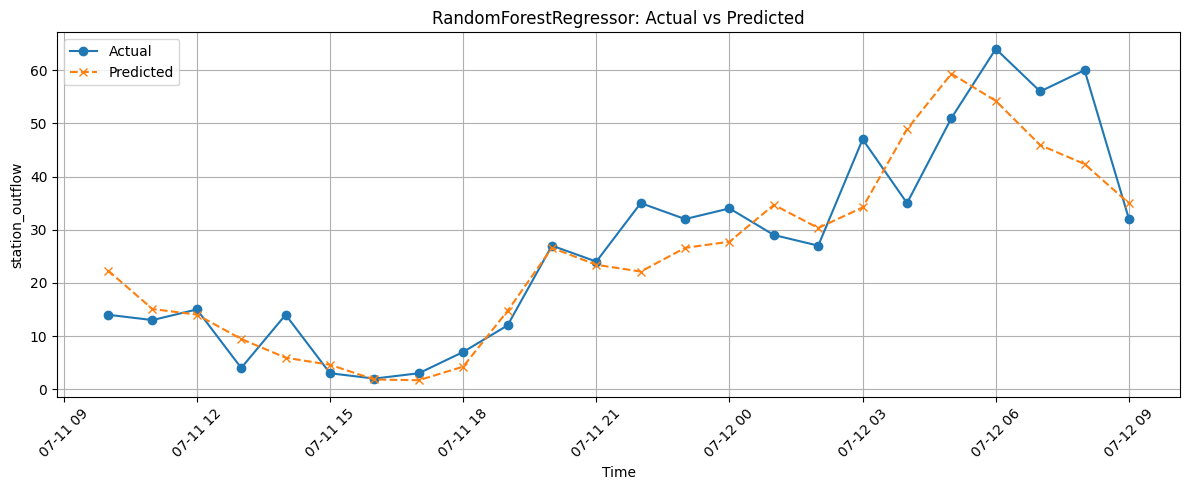

In [57]:
### plot final results 
for result in final_results_outflow:
    model_name = result["model_name"]
    pred_df = result["predictions"]

    plot_pdf = (
        pred_df
        .select("ts_hour", TARGET_COL, "prediction")
        .orderBy("ts_hour")
        .limit(24)
        .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(plot_pdf["ts_hour"], plot_pdf[TARGET_COL], label="Actual", marker="o")
    plt.plot(plot_pdf["ts_hour"], plot_pdf["prediction"], label="Predicted", linestyle="--", marker="x")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Saving the best trained OUTFLOW model

In [58]:
best_outflowModeling_result = min(final_results_outflow, key=lambda x: x["mae"])

best_outflow_model_name = best_outflowModeling_result["model_name"]
best_outflow_model = best_outflowModeling_result["fitted_model"]

print("Best model:", best_outflow_model_name)
print("MAE:", best_outflowModeling_result["mae"])
print("RMSE:", best_outflowModeling_result["rmse"])
print("R2:", best_outflowModeling_result["r2"])

Best model: GBTRegressor
MAE: 3.5177208248417933
RMSE: 5.369103144642521
R2: 0.8993282780224505


In [59]:
save_path = f"outputModels/best_outflow_model_{best_outflow_model_name}"
best_outflow_model.write().overwrite().save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: outputModels/best_outflow_model_GBTRegressor


## Netflow evaluation on post-2025-08-01 test window

Use the final best trained inflow model and final best trained outflow model on the explicit holdout window where `ts_hour >= 2025-08-01`, then compute:

`model_netflow = model_inflow - model_outflow`

Evaluate this against `station_netflow`, including the custom asymmetric loss from `yc__loss_func.py`.


In [60]:
from pyspark.ml.regression import RandomForestRegressionModel, GBTRegressionModel

best_inflow_model = RandomForestRegressionModel.load(
    "./outputModels/best_inflow_model_RandomForestRegressor"
)
best_outflow_model = GBTRegressionModel.load(
    "./outputModels/best_outflow_model_GBTRegressor"
)


In [61]:

# Build an explicit cutoff-based test input: all rows on/after 2025-08-01
cutoff_date = "2025-08-01"

cutoff_train_df = gold_0001_df.filter(F.col("ts_hour") < F.lit(cutoff_date))
cutoff_test_df = gold_0001_df.filter(F.col("ts_hour") >= F.lit(cutoff_date))

cutoff_fill_map = {c: 0.0 for c in MODEL_NUMERIC_COLS}
cutoff_fill_map.update({c: 0 for c in MODEL_BOOLEAN_COLS})

cutoff_train_df = cutoff_train_df.fillna(cutoff_fill_map)
cutoff_test_df = cutoff_test_df.fillna(cutoff_fill_map)

cutoff_indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in MODEL_CATEGORICAL_COLS
]
cutoff_encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"])
    for c in MODEL_CATEGORICAL_COLS
]

cutoff_feature_inputs = (
    MODEL_NUMERIC_COLS
    + MODEL_BOOLEAN_COLS
    + [f"{c}_ohe" for c in MODEL_CATEGORICAL_COLS]
)

cutoff_assembler = VectorAssembler(
    inputCols=cutoff_feature_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)
cutoff_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,
    withStd=True
)

cutoff_prep_pipe = Pipeline(stages=cutoff_indexers + cutoff_encoders + [cutoff_assembler, cutoff_scaler])
cutoff_prep_model = cutoff_prep_pipe.fit(cutoff_train_df)

cutoff_test_ready = cutoff_prep_model.transform(cutoff_test_df)

print(f"Cutoff date: {cutoff_date}")
print(f"Cutoff-train rows: {cutoff_train_df.count()}")
print(f"Cutoff-test rows: {cutoff_test_df.count()}")


Cutoff date: 2025-08-01
Cutoff-train rows: 20185
Cutoff-test rows: 4429


In [62]:
# Null-safe netflow evaluation block

from pyspark.sql import functions as F
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

# Score the explicit post-2025-08-01 test input using the best trained inflow and outflow models
best_inflow_pred_cutoff = (
    best_inflow_model
    .transform(cutoff_test_ready)
    .select("ts_hour", F.col("prediction").alias("model_inflow"))
    .dropDuplicates(["ts_hour"])
)

best_outflow_pred_cutoff = (
    best_outflow_model
    .transform(cutoff_test_ready)
    .select("ts_hour", F.col("prediction").alias("model_outflow"))
    .dropDuplicates(["ts_hour"])
)

optional_dashboard_cols = [
    c for c in ["num_available_bikes", "num_available_docks"]
    if c in cutoff_test_df.columns
]

netflow_eval_df = (
    cutoff_test_df
    .select("ts_hour", "station_netflow", *optional_dashboard_cols)
    .join(best_inflow_pred_cutoff, on="ts_hour", how="inner")
    .join(best_outflow_pred_cutoff, on="ts_hour", how="inner")
    .withColumn("model_netflow", F.col("model_inflow") - F.col("model_outflow"))
)

# Debug null counts before evaluation
null_check_df = netflow_eval_df.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("station_netflow").isNull().cast("int")).alias("null_station_netflow"),
    F.sum(F.col("model_inflow").isNull().cast("int")).alias("null_model_inflow"),
    F.sum(F.col("model_outflow").isNull().cast("int")).alias("null_model_outflow"),
    F.sum(F.col("model_netflow").isNull().cast("int")).alias("null_model_netflow"),
)

null_check_df.show()

# Keep only complete rows for metric evaluation
netflow_eval_clean_df = (
    netflow_eval_df
    .filter(
        F.col("station_netflow").isNotNull() &
        F.col("model_inflow").isNotNull() &
        F.col("model_outflow").isNotNull() &
        F.col("model_netflow").isNotNull()
    )
    .withColumn(
        "asymmetric_loss_rmse_row",
        asymmetric_loss_col(
            y_true=F.col("station_netflow"),
            y_pred=F.col("model_netflow"),
            alpha=1.25,
            beta=1.0,
            loss_type="rmse",
        ),
    )
    .withColumn(
        "asymmetric_loss_mae_row",
        asymmetric_loss_col(
            y_true=F.col("station_netflow"),
            y_pred=F.col("model_netflow"),
            alpha=1.25,
            beta=1.0,
            loss_type="mae",
        ),
    )
)

# Optional: inspect dropped rows if needed
dropped_rows_df = netflow_eval_df.filter(
    F.col("station_netflow").isNull() |
    F.col("model_inflow").isNull() |
    F.col("model_outflow").isNull() |
    F.col("model_netflow").isNull()
)

print("Rows kept for evaluation:", netflow_eval_clean_df.count())
print("Rows dropped due to nulls:", dropped_rows_df.count())

netflow_metrics = {
    "rmse": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="rmse"
    ).evaluate(netflow_eval_clean_df),
    "mae": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="mae"
    ).evaluate(netflow_eval_clean_df),
    "r2": RegressionEvaluator(
        labelCol="station_netflow",
        predictionCol="model_netflow",
        metricName="r2"
    ).evaluate(netflow_eval_clean_df),
    "asymmetric_rmse_mean": asymmetric_loss_mean(
        netflow_eval_clean_df,
        y_true_col="station_netflow",
        y_pred_col="model_netflow",
        alpha=1.25,
        beta=1.0,
        loss_type="rmse",
    ),
    "asymmetric_mae_mean": asymmetric_loss_mean(
        netflow_eval_clean_df,
        y_true_col="station_netflow",
        y_pred_col="model_netflow",
        alpha=1.25,
        beta=1.0,
        loss_type="mae",
    ),
}

display(pd.DataFrame([netflow_metrics]))

output_cols = ["ts_hour", "station_netflow", "model_inflow", "model_outflow", "model_netflow"]
output_cols += optional_dashboard_cols

netflow_output_df = (
    netflow_eval_clean_df
    .select(*output_cols)
    .orderBy("ts_hour")
)

netflow_output_df.show(20, truncate=False)

+----------+--------------------+-----------------+------------------+------------------+
|total_rows|null_station_netflow|null_model_inflow|null_model_outflow|null_model_netflow|
+----------+--------------------+-----------------+------------------+------------------+
|      4429|                   0|                0|                 0|                 0|
+----------+--------------------+-----------------+------------------+------------------+

Rows kept for evaluation: 4429
Rows dropped due to nulls: 0


,rmse,mae,r2,asymmetric_rmse_mean,asymmetric_mae_mean
0,5.093803,3.381251,0.115652,29.08714,3.791814


+-------------------+---------------+------------------+------------------+--------------------+
|ts_hour            |station_netflow|model_inflow      |model_outflow     |model_netflow       |
+-------------------+---------------+------------------+------------------+--------------------+
|2025-08-01 00:00:00|-6             |24.18523760489296 |28.954695710517143|-4.769458105624182  |
|2025-08-01 01:00:00|2              |25.61228818974458 |26.263463957297358|-0.651175767552779  |
|2025-08-01 02:00:00|-4             |23.653657824501856|25.298492228493103|-1.644834403991247  |
|2025-08-01 03:00:00|-11            |26.454303453965625|29.27318554911641 |-2.8188820951507836 |
|2025-08-01 04:00:00|-1             |38.09185037381893 |41.494571238912705|-3.4027208650937766 |
|2025-08-01 05:00:00|-1             |54.260772673768976|58.731138549102376|-4.4703658753334    |
|2025-08-01 06:00:00|-7             |51.99950818812707 |57.62967206441756 |-5.630163876290489  |
|2025-08-01 07:00:00|-16      

In [63]:
"""adding the canonical station id column for dashboard compatibility""" 
# all rows will have the same value since this is a single-station model
netflow_output_df = netflow_output_df.withColumn(
    "canonical_station_id",
    F.lit("STN_0001")
)
netflow_output_df = netflow_output_df.select(
    "canonical_station_id",
    "ts_hour",
    "station_netflow",
    "model_netflow"
)

In [64]:
print(netflow_output_df.show(20, truncate=False))
netflow_output_df.write.mode("overwrite").option("header", "true").csv("./outputNetflowEvaluation_STN0001/netflow_predictions.csv")

+--------------------+-------------------+---------------+--------------------+
|canonical_station_id|ts_hour            |station_netflow|model_netflow       |
+--------------------+-------------------+---------------+--------------------+
|STN_0001            |2025-08-01 00:00:00|-6             |-4.769458105624182  |
|STN_0001            |2025-08-01 01:00:00|2              |-0.651175767552779  |
|STN_0001            |2025-08-01 02:00:00|-4             |-1.644834403991247  |
|STN_0001            |2025-08-01 03:00:00|-11            |-2.8188820951507836 |
|STN_0001            |2025-08-01 04:00:00|-1             |-3.4027208650937766 |
|STN_0001            |2025-08-01 05:00:00|-1             |-4.4703658753334    |
|STN_0001            |2025-08-01 06:00:00|-7             |-5.630163876290489  |
|STN_0001            |2025-08-01 07:00:00|-16            |-2.135893070105695  |
|STN_0001            |2025-08-01 08:00:00|-23            |-4.938438269829277  |
|STN_0001            |2025-08-01 09:00:0

### station prediction VS actual plots

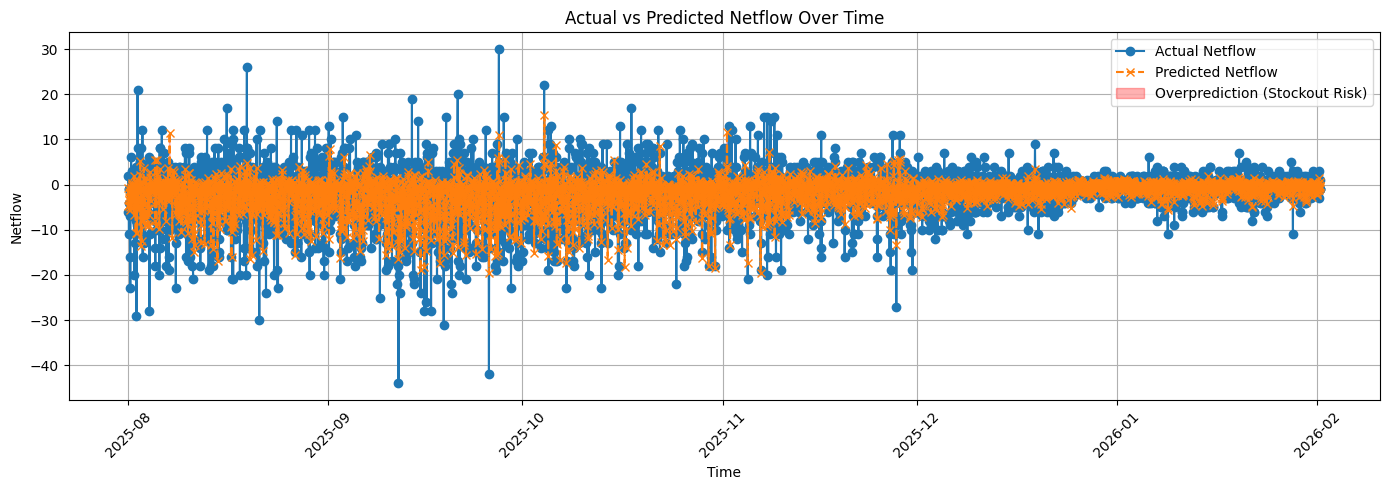

In [65]:
plot_pdf = (
    netflow_output_df
    .select("ts_hour", "station_netflow", "model_netflow")
    .orderBy("ts_hour")
    .toPandas()
)

plt.figure(figsize=(14, 5))

plt.plot(plot_pdf["ts_hour"], plot_pdf["station_netflow"], label="Actual Netflow", marker="o")
plt.plot(plot_pdf["ts_hour"], plot_pdf["model_netflow"], label="Predicted Netflow", linestyle="--", marker="x")

plt.title("Actual vs Predicted Netflow Over Time")
plt.xlabel("Time")
plt.ylabel("Netflow")
plt.fill_between(
    plot_pdf["ts_hour"],
    plot_pdf["station_netflow"],
    plot_pdf["model_netflow"],
    where=(plot_pdf["model_netflow"] > plot_pdf["station_netflow"]),
    color="red",
    alpha=0.3,
    label="Overprediction (Stockout Risk)"
)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



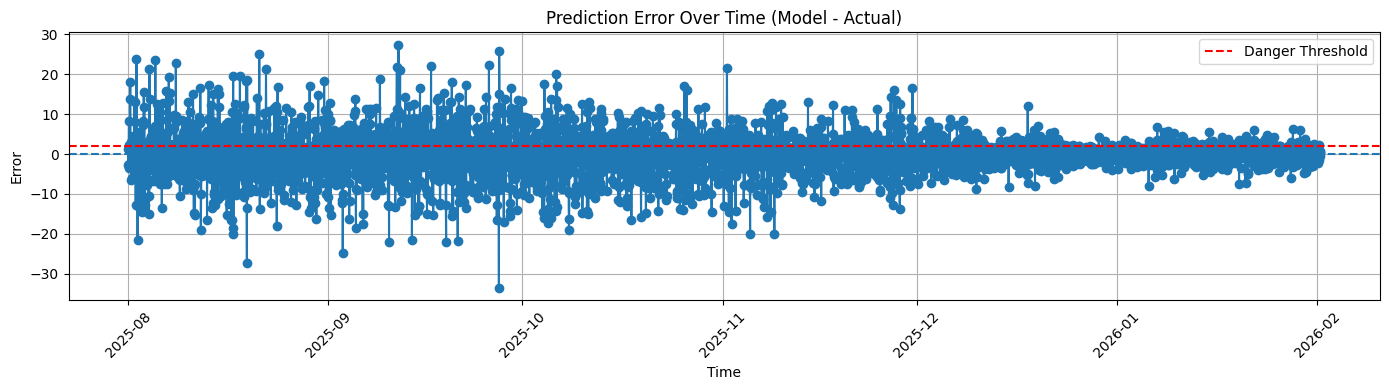

In [66]:
plot_pdf["error"] = plot_pdf["model_netflow"] - plot_pdf["station_netflow"]

plt.figure(figsize=(14, 4))

plt.plot(plot_pdf["ts_hour"], plot_pdf["error"], marker="o")

plt.axhline(0, linestyle="--")
plt.axhline(2, color="red", linestyle="--", label="Danger Threshold")

plt.title("Prediction Error Over Time (Model - Actual)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

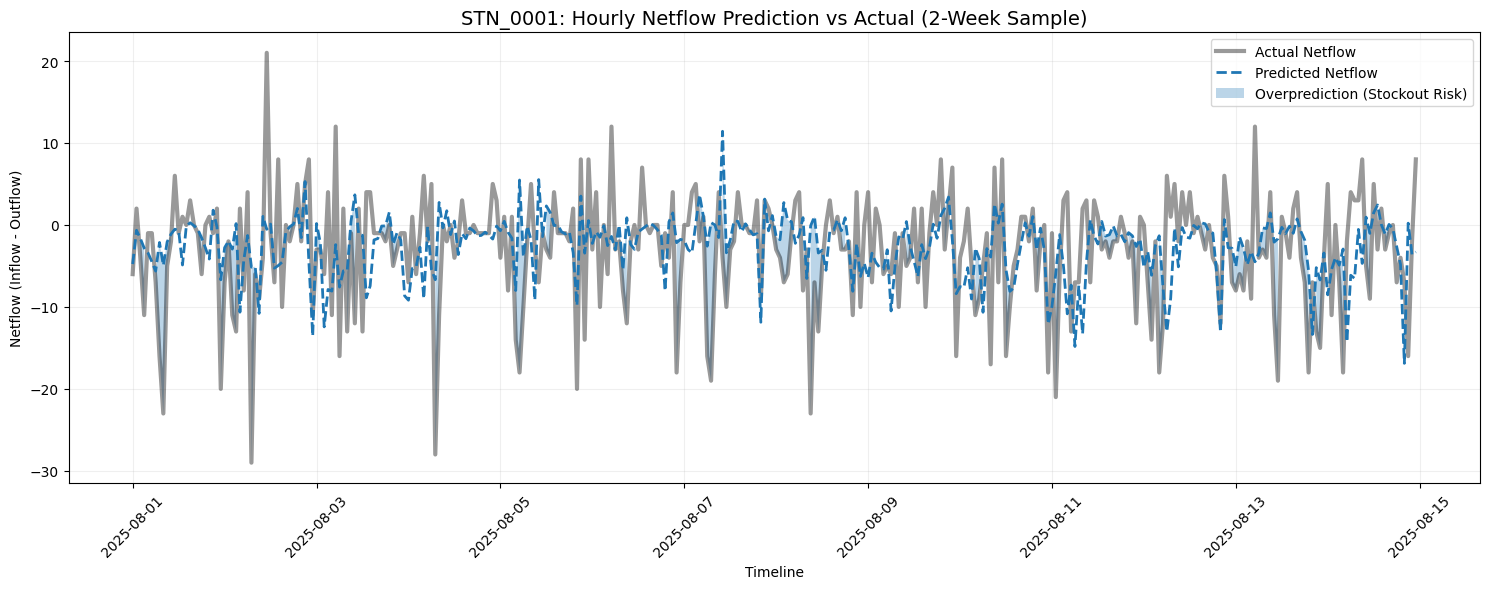

In [67]:
# 1. Extract 2 weeks (336 hours)
plot_pd = (
    netflow_output_df
    .orderBy("ts_hour")
    .limit(336)
    .select("ts_hour", "station_netflow", "model_netflow")
    .toPandas()
)

# 2. Plot
plt.figure(figsize=(15, 6))

plt.plot(
    plot_pd['ts_hour'],
    plot_pd['station_netflow'],
    label='Actual Netflow',
    color='black',
    alpha=0.4,
    linewidth=3
)

plt.plot(
    plot_pd['ts_hour'],
    plot_pd['model_netflow'],
    label='Predicted Netflow',
    linestyle='--',
    linewidth=2
)

plt.title("STN_0001: Hourly Netflow Prediction vs Actual (2-Week Sample)", fontsize=14)
plt.ylabel("Netflow (Inflow - Outflow)")
plt.xlabel("Timeline")
plt.fill_between(
    plot_pd["ts_hour"],
    plot_pd["station_netflow"],
    plot_pd["model_netflow"],
    where=(plot_pd["model_netflow"] > plot_pd["station_netflow"]),
    alpha=0.3,
    label="Overprediction (Stockout Risk)"
)
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Visualising the loss 

Understanding
- how often did it overpredict?
- how much risky loss accumulated?

`Cumulative asymmetric loss` and `cumulative overprediction risk `better reflect business cost because overestimating netflow can lead to stockouts and lost rides. Since prior research indicates that the `cost of lost rides exceeds the cost of over-incentivizing riders`, these risk-weighted plots provide a more decision-relevant view of model performance.

`Standard absolute error` measures total forecast deviation.

In [68]:
from pyspark.sql.window import Window

# Running window by time
loss_window = Window.orderBy("ts_hour").rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Build hourly and cumulative error/loss columns
cum_loss_sdf = (
    netflow_eval_clean_df
    .withColumn("abs_error", F.abs(F.col("station_netflow") - F.col("model_netflow")))
    .withColumn(
        "signed_error",
        F.col("model_netflow") - F.col("station_netflow")
    )
    .withColumn("cumulative_abs_error", F.sum("abs_error").over(loss_window))
    .withColumn("cumulative_asym_rmse_loss", F.sum("asymmetric_loss_rmse_row").over(loss_window))
    .withColumn("cumulative_asym_mae_loss", F.sum("asymmetric_loss_mae_row").over(loss_window))
    .select(
        "ts_hour",
        "abs_error",
        "signed_error",
        "asymmetric_loss_rmse_row",
        "asymmetric_loss_mae_row",
        "cumulative_abs_error",
        "cumulative_asym_rmse_loss",
        "cumulative_asym_mae_loss",
    )
)

cum_loss_pd = cum_loss_sdf.orderBy("ts_hour").toPandas()

26/04/18 16:59:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:59:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:59:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:59:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:59:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 16:59:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 1

#### Plot 1: cumulative absolute error + hourly absolute error

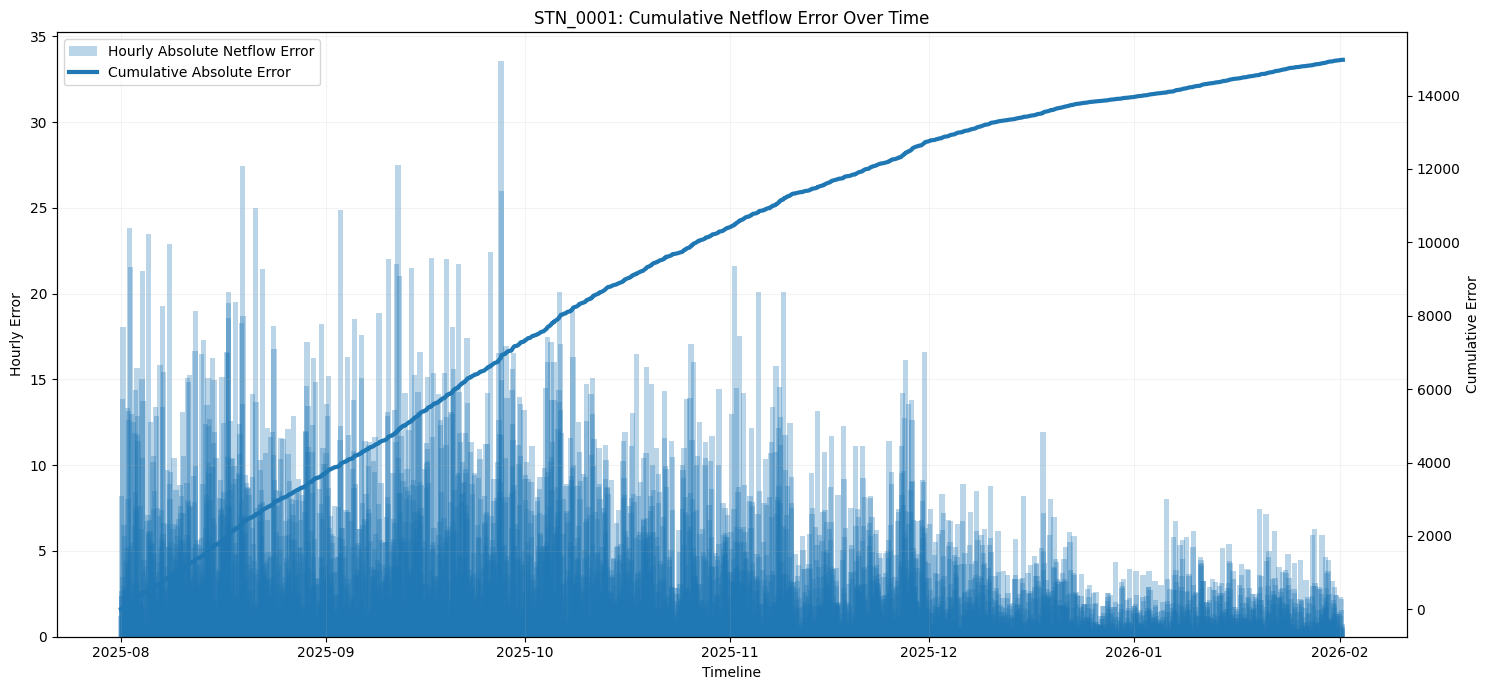

Total cumulative absolute netflow error: 14,975.56


In [69]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["abs_error"],
    alpha=0.3,
    label="Hourly Absolute Netflow Error"
)
ax1.set_ylabel("Hourly Error")

ax2 = ax1.twinx()
ax2.plot(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["cumulative_abs_error"],
    linewidth=3,
    label="Cumulative Absolute Error"
)
ax2.set_ylabel("Cumulative Error")

plt.title("STN_0001: Cumulative Netflow Error Over Time")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_abs_error = cum_loss_pd["cumulative_abs_error"].iloc[-1]
print(f"Total cumulative absolute netflow error: {total_abs_error:,.2f}")

#### Plot 2: cumulative asymmetric loss

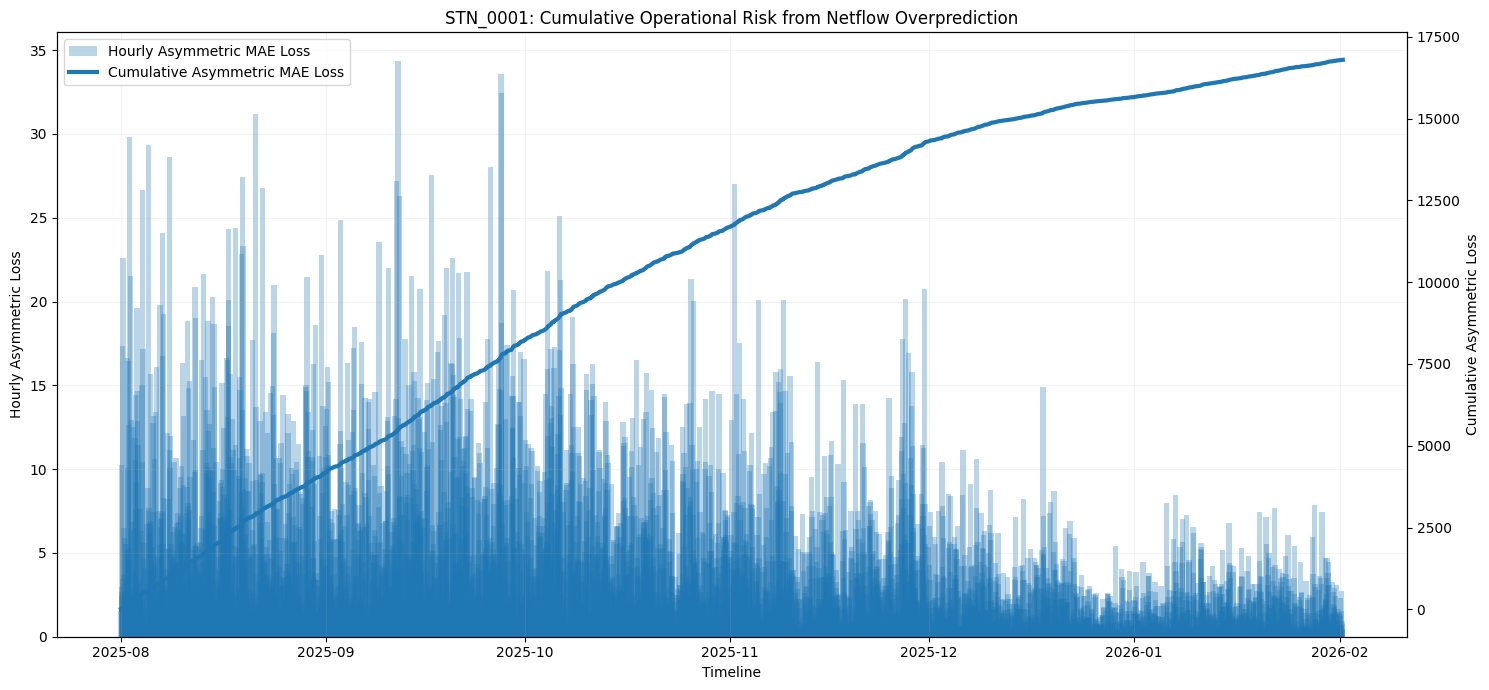

Total cumulative asymmetric MAE loss: 16,793.94


In [70]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["asymmetric_loss_mae_row"],
    alpha=0.3,
    label="Hourly Asymmetric MAE Loss"
)
ax1.set_ylabel("Hourly Asymmetric Loss")

ax2 = ax1.twinx()
ax2.plot(
    cum_loss_pd["ts_hour"],
    cum_loss_pd["cumulative_asym_mae_loss"],
    linewidth=3,
    label="Cumulative Asymmetric MAE Loss"
)
ax2.set_ylabel("Cumulative Asymmetric Loss")

plt.title("STN_0001: Cumulative Operational Risk from Netflow Overprediction")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_asym_mae = cum_loss_pd["cumulative_asym_mae_loss"].iloc[-1]
print(f"Total cumulative asymmetric MAE loss: {total_asym_mae:,.2f}")

#### Plot 3: cumulative risky overprediction only –> stockout???

26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 17:00:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/18 1

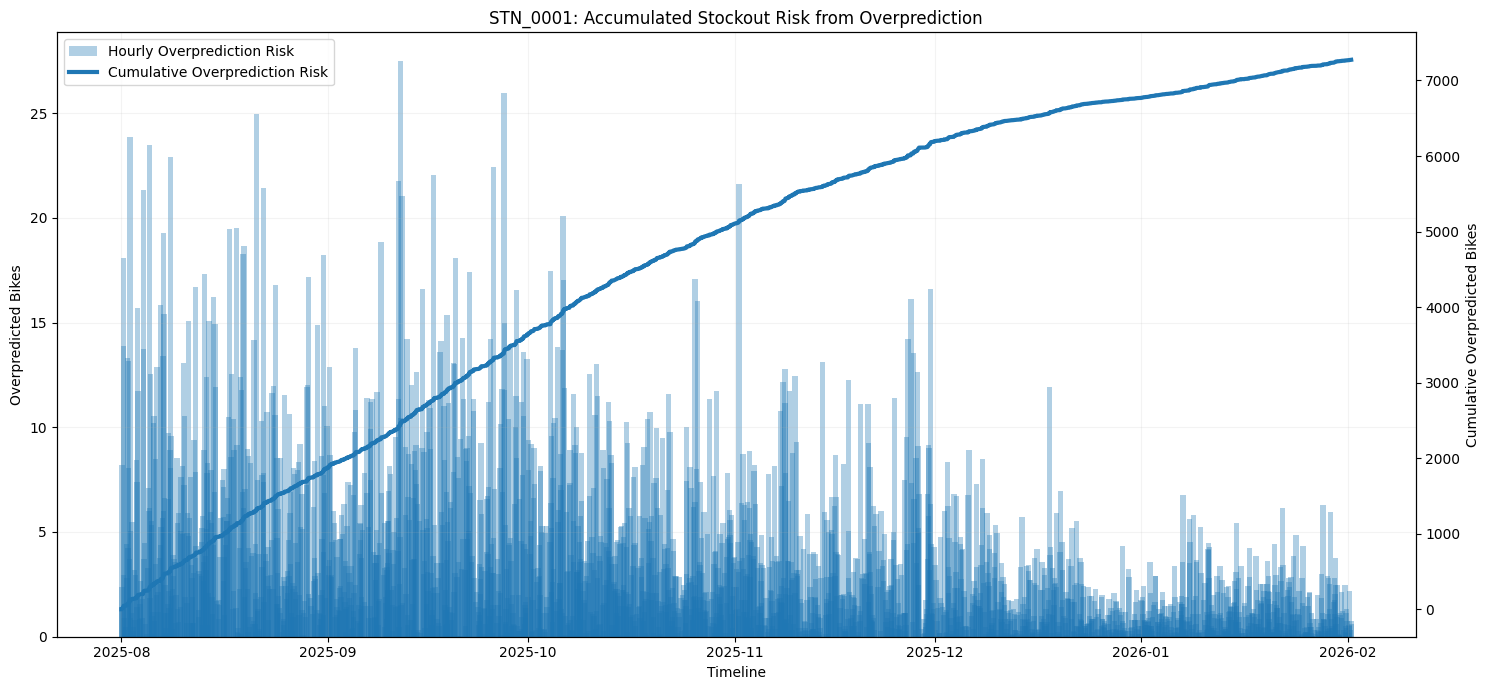

Total cumulative overprediction risk: 7,273.52 bikes


In [71]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

risk_window = Window.orderBy("ts_hour").rowsBetween(Window.unboundedPreceding, Window.currentRow)

risk_sdf = (
    netflow_eval_clean_df
    .withColumn(
        "overprediction_amount",
        F.when(
            F.col("model_netflow") > F.col("station_netflow"),
            F.col("model_netflow") - F.col("station_netflow")
        ).otherwise(F.lit(0.0))
    )
    .withColumn(
        "cumulative_overprediction",
        F.sum("overprediction_amount").over(risk_window)
    )
    .select("ts_hour", "overprediction_amount", "cumulative_overprediction")
)

risk_pd = risk_sdf.orderBy("ts_hour").toPandas()

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    risk_pd["ts_hour"],
    risk_pd["overprediction_amount"],
    alpha=0.35,
    label="Hourly Overprediction Risk"
)
ax1.set_ylabel("Overpredicted Bikes")

ax2 = ax1.twinx()
ax2.plot(
    risk_pd["ts_hour"],
    risk_pd["cumulative_overprediction"],
    linewidth=3,
    label="Cumulative Overprediction Risk"
)
ax2.set_ylabel("Cumulative Overpredicted Bikes")

plt.title("STN_0001: Accumulated Stockout Risk from Overprediction")
ax1.set_xlabel("Timeline")
ax1.grid(True, alpha=0.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

total_risk = risk_pd["cumulative_overprediction"].iloc[-1]
print(f"Total cumulative overprediction risk: {total_risk:,.2f} bikes")